## Legacy

### Inspect means for data with varying thetas

In [ ]:
# Create figures and store for later
plt.ioff()
fz, axz = plt.subplots(num="fz")
xaxis = range(1,13)
axz.axhline(y=0.0, linestyle="--", color="k", alpha=0.6)
xmeans = {}

for key in z_moments.keys():
    num = len(z_moments[key])
    xmeans.update({key: convert_z_to_x(np.array(z_moments[key]))})
    marker=rng.integers(0,len(markers), 1, dtype=int)
    a=axz.scatter(xaxis[:num], z_moments[key], label=thetas[key], marker=markers[marker[0]])
    c=a.get_facecolor()[0]
    axz.scatter(0, 0.0, color=c, marker=markers[marker[0]])
axz.set_xlabel("RG step")
axz.set_ylabel(r"$z_{\text{mean}}$")
axz.set_title(r"$z_{\text{mean}}$ vs RG steps for various $\theta$")
axz.legend(loc="upper right", bbox_to_anchor=(1.2, 1.0))

fx, axx = plt.subplots(num="fx")
axx.axhline(y=np.log(1 + np.sqrt(2)), linestyle="--", color="k", label=r"x=ln$(1+\sqrt{2})$", alpha=0.5)

for key in xmeans.keys():
    num = len(xmeans[key])
    marker=rng.integers(0,len(markers), 1, dtype=int)
    a=axx.scatter(xaxis[:num], xmeans[key], label=thetas[key], marker=markers[marker[0]])
    c=a.get_facecolor()[0]
    axx.scatter(0.0, np.log(1+np.sqrt(2)), color=c, marker=markers[marker[0]])

axx.set_xlabel("RG step")
axx.set_ylabel("x")
axx.set_title(r"x vs RG steps for various $\theta$")
axx.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))

fg, axg = plt.subplots(num="fg")
axg.axhline(y=0.5, linestyle="--", color="k", label="g=0.5", alpha=0.5)

for key in g_moments.keys():
    num = len(g_moments[key])
    marker=rng.integers(0,len(markers), 1, dtype=int)
    a=axg.scatter(xaxis[:num], g_moments[key], label=thetas[key], marker=markers[marker[0]])
    c=a.get_facecolor()[0]
    axg.scatter(0.0,0.5, color=c, marker=markers[marker[0]])
axg.set_xlabel("RG step")
axg.set_ylabel(r"$g_{\text{mean}}$")
axg.set_title(r"$g_{\text{mean}}$ vs RG steps for various $\theta$")
axg.legend(loc="upper right", bbox_to_anchor=(1.2, 1.0))


### Inspect data for varying g, fixed $\theta = \pi/8$

In [ ]:
markers = [",", "o", "v", "^", "1", "2", "3", "4", "8", "s", "p", "P", "*", "+"]
colors = []
# Now we see the data for varying gs
gvals = [0.1, 0.2, 0.6, 0.7, 0.9]
g_hists = defaultdict(list)
z_mom = defaultdict(list)
g_mom = defaultdict(list)
z_med = defaultdict(list)
z_mode = defaultdict(list)
g_med = defaultdict(list)
g_mode = defaultdict(list)
mcopy = markers.copy()
pres_vals = []
for gval in gvals:
    z_mom[f"{gval}"] = load_fixed_theta_moments(12, "g", 2, gval, "z")
    g_mom[f"{gval}"] = load_fixed_theta_moments(12, "g", 2, gval, "g")
    z_med[f"{gval}"], z_mode[f"{gval}"] = get_median_and_mode(12, "z", f"theta_2_g{gval}_numerical_shreyas", 2)
    g_med[f"{gval}"], g_mode[f"{gval}"] = get_median_and_mode(12, "g", f"theta_2_g{gval}_numerical_shreyas", 2)
    try:
        g_hists[f"{gval}"] = load_hists(12, "g", 2, gval, "g")
        pres_vals.append(gval)
    except FileNotFoundError:
        continue
glabs = gvals
glabs.insert(2,0.5)
m = rng.integers(0, len(markers), len(glabs))
mcopy = np.array(markers)[m]
vth = list(THETA_DICT.keys())[1:-1]
g09th5 = load_fixed_theta_moments(12, "g", 5, 0.9, "g")
# print(g09th5)
# print(g_moments['1'])
# print(g_mom.keys())

In [ ]:
for val in gvals:
    plt.scatter(range(len(z_mode[f"{val}"])),z_mode[f"{val}"], label=f"{val}")
plt.legend()
# print(z_mode)

In [ ]:
# plt.ioff()
ftz, axtz = plt.subplots(num="ftz")
glabel = r"$g_{\text{init}}$"
# xaxis = range(12)
axtz.axhline(y=0.0, linestyle="--", color="k", alpha=0.6, label="z=0")
axtz.axhline(y=25.0, linestyle="--", color="r", alpha=0.6, label="z=25")
xtmeans = {}
i = 0
zm = np.array([float(k) for k in z_mom.keys()])
xinit = convert_z_to_x(zm)
for key in z_mom.keys():
    num = len(z_mom[key])
    xtmeans.update({key: convert_z_to_x(np.array(z_mom[key]))})
    marker=rng.integers(0,len(markers), 1, dtype=int)
    a =axtz.scatter(xaxis[:num], z_mom[key], label=f"{glabel}={key}",marker=markers[marker[0]])
    c = a.get_facecolor()[0]
    axtz.scatter(0.0, convert_g_to_z(np.array(float(key))), color=c,marker=markers[marker[0]])
axtz.set_xlabel("RG step")
axtz.set_ylabel(r"$z_{\text{mean}}$")
axtz.set_title(r"$z_{\text{mean}}$ with $\theta = \pi/8$ vs RG steps for various $g_{init}$")
axtz.legend(loc="upper right", bbox_to_anchor=(1.25, 1.0))

ftx, axtx = plt.subplots(num="ftx")
axtx.axhline(y=np.log(1 + np.sqrt(2)), linestyle="--", color="k", label=r"x=ln$(1+\sqrt{2})$", alpha=0.5)
i=0
for key in xtmeans.keys():
    num = len(xtmeans[key])
    marker=rng.integers(0,len(markers), 1, dtype=int)
    a = axtx.scatter(xaxis[:num], xtmeans[key], label=f"{glabel}={key}",marker=markers[marker[0]])
    c = a.get_facecolor()[0]
    axtx.scatter(0.0, xinit[i], color=c,marker=markers[marker[0]])
    i+=1
axtx.set_xlabel("RG step")
axtx.set_ylabel("x")
axtx.set_title(r"x vs RG steps with $\theta = \pi/8$ for various $g_{init}$")
axtx.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))

ftg, axtg = plt.subplots(num="ftg")
axtg.axhline(y=0.5, linestyle="--", color="k", label="g=0.5", alpha=0.5)
# axtg.scatter(xaxis)
for key in g_mom.keys():
    num = len(g_mom[key])
    marker=rng.integers(0,len(markers), 1, dtype=int)
    a = axtg.scatter(xaxis[:num], g_mom[key], label=f"{glabel}={key}",marker=markers[marker[0]])
    c = a.get_facecolor()[0]
    axtg.scatter(0.0, float(key), color=c,marker=markers[marker[0]])
axtg.set_xlabel("RG step")
axtg.set_ylabel(r"$g_{\text{mean}}$")
axtg.set_title(r"$g_{\text{mean}}$ with $\theta = \pi/8$ vs RG steps for various $g_{init}$")
axtg.legend(loc="upper right", bbox_to_anchor=(1.25, 1.0))

### Print plots for all 3 vars and desired number of steps

In [ ]:
# Helper function
def theta_var_plot(s: int, var: str, save: bool = False):
    moments = defaultdict(list)
    mom = defaultdict(list)
    # mainval = 0.5
    if var == "z":
        labs = convert_g_to_z(np.array(glabs))
        mainval = convert_g_to_z(np.array(0.5))
        ninevar = convert_g_to_z(np.array(0.9))
        for key in g_moments.keys():
            moments[key] = list(convert_g_to_z(np.array(g_moments[key])))
        for key in g_mom.keys():
            mom[key] = list(convert_g_to_z(np.array(g_mom[key])))
        var09th5 = list(convert_g_to_z(np.array(g09th5)))
    elif var == "x":
        labs = convert_g_to_x(np.array(glabs))
        mainval = convert_g_to_x(np.array(0.5))
        ninevar = convert_g_to_x(np.array(0.9))
        for key in g_moments.keys():
            moments[key] = list(convert_g_to_x(np.array(g_moments[key])))
        for key in g_mom.keys():
            mom[key] = list(convert_g_to_x(np.array(g_mom[key])))
        var09th5 = list(convert_g_to_x(np.array(g09th5)))
    else:
        labs = glabs
        mainval = 0.5
        ninevar = 0.9
        var09th5 = g09th5
        moments = g_moments.copy()
        mom = g_mom.copy()

    # print(moments)
    # print(mom)
    # print(var09th5)
    narr = np.zeros(shape=(len(labs), s+2))
    narr[:,0] = labs
    narr[:,1] = np.tile(mainval, 6).T
    sj = 0
    for key in moments.keys():
        narr[sj, 0] = THETA_DICT[key]
        # c = a.get_facecolor()[0]
        for i in range(s):
            narr[sj, i+2] = moments[key][i]
        sj += 1
    # print(narr)
    # pres_vals.append(0.5)
    plt.figure(figsize=(10,6))
    k=0
    for ind, gv in enumerate(glabs):
        if gv == 0.5:
            plt.scatter(narr[:, 2:], np.tile(narr[:,0], s).reshape(s, 6).T, color = "m", marker = mcopy[k], alpha=0.7)
            plt.scatter(narr[:, 1], narr[:,0], color="m", marker=mcopy[k], label=f"g_init = {gv}", s = 100, alpha=0.7)
            k+=1
            continue
        # steps = len(g_hists[f"{gv}"])
        a = plt.scatter(labs[ind], np.pi/8, label=f"g_init = {gv}", marker=mcopy[k], alpha=0.9, s=100)
        c = a.get_facecolor()[0]
        for i in range(s):
            try:
                plt.scatter(mom[f"{gv}"][i], np.pi/8, marker=mcopy[k], color=c)
            except IndexError:
                print(f"{var} = {labs[ind]:.3f} data does not have more than {i} steps. Proceeding with next")
                # continue

        if gv == ninevar:
            plt.scatter(labs[ind], THETA_DICT["5"], color=c, marker=mcopy[k], alpha=0.9, s = 100)
            plt.scatter(var09th5[:s], np.tile(THETA_DICT["5"], s), color=c, marker=mcopy[k])
        k+=1
        # plt.arrow(gv, np.pi/8, -(g_mom[f"{gv}"][-1]),0, color=c, head_width=0.03, alpha=0.5)


    plt.title(r"Plot of $\theta$ and {var} over {s} RG steps".format(var=var, s=s))
    plt.xlabel(f"{var}")
    thsa = list((THETA_DICT.keys()))
    ls = [thetas[l] for l in thsa if l in thetas.keys()]
    plt.xticks(labs)
    plt.yticks(list(THETA_DICT.values())[1:-2],ls)
    plt.grid(True, alpha=0.8)
    plt.ylabel(r"$\theta$")
    plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.0))
    if var == "z":
        plt.xlim((-3.0, 3.0))
    elif var == "x":
        plt.xlim((0.0, 2.0))
    # plt.show()
    if save:
        varfolder = f"{qshe_test_dir}/Theta_{var}"
        os.makedirs(varfolder, exist_ok=True)
        plt.savefig(f"{varfolder}/theta_{var}_{s}steps.png", dpi=150, bbox_inches="tight")
    # np.histogram2d()

In [ ]:
# close_old_plots()
# vars = ["z", "x", "g"]
# steps = 13
# for var in vars:
#     for step in range(steps):
#         close_old_plots()
#         theta_var_plot(step, var)

In [ ]:
close_old_plots() # Extra functionality if required
# Display previously generated figures
from IPython.display import display

# display(fz)
# display(fg)
# display(fx)
# display(ftz)
# display(ftx)
# display(ftg)

### Some new checks

In [ ]:
def quick_trials(thetas, phis, g_init, samples, nsteps, metric = "mean", var = "g"):
    gmeans = defaultdict(list)
    for theta in thetas:
        costheta = np.cos(theta)**2
        sintheta = np.sin(theta)**2
        t_init = np.full((samples), fill_value = np.sqrt(costheta*g_init))
        f_init = np.full((samples), fill_value = np.sqrt(sintheta*g_init))
        for step in range(nsteps):
            indices = rng.integers(0, samples, (samples, 5))
            ts = np.take(t_init, indices)
            fs = np.take(f_init, indices)
            tp = numerical_solver(ts, fs, phis, samples, 2, [1.0,0.0,0.0,0.0], samples)
            fp = numerical_solver(ts, fs, phis, samples, 17, [1.0,0.0,0.0,0.0], samples)
            gp = tp**2 + fp**2
            if var == "z":
                gp = convert_g_to_z(gp) # This is z, named gp just for ease of use
            elif var == "x":
                gp = convert_g_to_x(gp) # This is x, named gp just for ease of use
            if metric == "mode":
                unique, counts = np.unique(gp, return_counts=True)
                maxunique = np.argmax(counts)
                mode = unique[maxunique]
                gmeans[step].append(mode)
            elif metric == "median":
                median = np.median(gp)
                gmeans[step].append(median)
            elif metric == "all":
                unique, counts = np.unique(gp, return_counts=True)
                maxunique = np.argmax(counts)
                mode = unique[maxunique]
                median = np.median(gp)
                gmean = np.mean(gp)
                gmeans[step].append((gmean, median, mode))
            else:
                gmean = np.mean(gp)
                gmeans[step].append(gmean)
            t_init = tp
            f_init = fp
        # print(f"Finished data gen for θ = {theta}")
    return gmeans

In [ ]:
ntheta = 11
num_g = 10
lower_g = 1e-6
upper_g = 0.7
n = 50000
nsteps = 2
c_indices = rng.integers(0, avail_colors, num_g)
m_indices = rng.integers(0, avail_markers, num_g)
colors = np.take(list(loaded_colors.keys()), c_indices)
marks = np.take(markers, m_indices)


### Sweep through $\theta \in [0, \pi/2]$ for each $\text{g}_{init} \in [0, 1]$

In [ ]:
thetas = np.linspace(0, np.pi/2, ntheta)
g_inits = np.linspace(lower_g, upper_g, num_g)
gs = {g_init: defaultdict(list) for g_init in g_inits}
for i,ginit in enumerate(g_inits):
    phis = generate_random_phases(n, rng, 16)
    gs[ginit] = quick_trials(thetas, phis, ginit, nsamples, nsteps)
    if i % 3 == 0:
        print(f"Finished data gen for g_init = {ginit}")


In [ ]:
view_step = 1
plt.figure(figsize=(12, 8))
min_g = 0
max_g = 9
xvals = convert_g_to_x(g_inits[min_g:max_g])
for i, ginit in enumerate(g_inits[min_g:max_g]):
    plt.axvline(x=ginit, linestyle="--", color = colors[i+1], label=f"g_init = {ginit:.3f}", alpha=0.8)
    plt.scatter(gs[ginit][view_step],thetas,  color=colors[i+1], marker=marks[i])
    plt.fill_betweenx(thetas, ginit, gs[ginit][view_step], color=colors[i+1], alpha=0.3)

# plt.axvline(0.0, linestyle="--", alpha=0.4, label=r"$\theta = 0$", color="m")
# plt.axvline(np.pi, linestyle="--", alpha=0.4, label=r"$\theta=\pi$", color="m")
plt.ylabel(r"$2\theta/\pi$")
plt.xlabel("g")
# plt.xlim((min_g/1.2, max_g*1.2))
plt.title(f"Plot of g_mean after {view_step+1} RG step for {ntheta} thetas and {nsamples} samples")
# plt.yticks(g_inits)
plt.yticks(thetas[::2], labels=[str(t) for t in thetas[::2]/(np.pi)])
# plt.xticks(g_inits[min_g:max_g])
# plt.xlim((g_inits[max(min_g-1, 0)], g_inits[min(max_g+1, num_g-1)]))
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.0))
plt.grid(alpha=0.5)
# plt.show()
os.makedirs(f"{qshe_test_dir}/Theta_G/{nsamples}samples/{view_step+1}steps", exist_ok=True)
plt.savefig(f"{qshe_test_dir}/Theta_G/{nsamples}samples/{view_step+1}steps/theta_g{g_inits[min_g]:.2f}-{g_inits[max_g]:.2f}_{ntheta}θ_{nsamples}samples_{view_step+1}steps.png", dpi=150, bbox_inches="tight")

### Sweep through $\text{g}_{init} \in [0, 1]$ with constant $\theta$

In [ ]:
ntheta = 1
num_g = 30
lower_g = 0.1
upper_g = 0.9
nsamples = 10000
nsteps = 6
c_indices = rng.integers(0, avail_colors, num_g)
m_indices = rng.integers(0, avail_markers, num_g)
colors = np.take(list(loaded_colors.keys()), c_indices)
marks = np.take(markers, m_indices)
var = "g"

In [ ]:
theta_fixed = np.full(ntheta, fill_value = 0)
g_s = np.linspace(lower_g, upper_g, num_g)
gms = {g_init: defaultdict(list) for g_init in g_s}
for i,ginit in enumerate(g_s):
    phis = generate_random_phases(nsamples, rng, 16)
    gms[ginit] = quick_trials(theta_fixed, phis, ginit, nsamples, nsteps, "all", var)
    if i % 5 == 0:
        print(f"Finished data gen for g_init = {ginit}")
print("Finished data gen")

In [ ]:
# print(gms[g_s[0]])
# print(convert_g_to_z(g_s[0:20]))
var = "z"


In [ ]:
view_step = 0
# plt.figure(figsize=(12, 8))
fig, axs = plt.subplots(1, 3, figsize=(24, 8))
min_g = 0
max_g = 30
minmean,minmed,minmode = 0,0,0
maxmean,maxmed,maxmode = 0,0,0
if var == "z":
    # gval_s  = convert_g_to_z(g_s)
    gval_s = np.log(g_s)
elif var == "x":
    gval_s = convert_g_to_x(g_s, theta_fixed[0])
else:
    gval_s = g_s
for step in range(nsteps):
    gmeans = []
    gmedians = []
    gmodes = []
    for i, ginit in enumerate(g_s[min_g:max_g]):
        gmean, gmedian, gmode = gms[ginit][step][0]
        if var == "x":
            gmean = convert_g_to_x(gmean, theta_fixed[0])
            gmedian = convert_g_to_x(gmedian, theta_fixed[0])
            gmode = convert_g_to_x(gmode, theta_fixed[0])
        elif var == "z":
            gmean = convert_g_to_z(gmean)
            gmedian = convert_g_to_z(gmedian)
            gmode = convert_g_to_z(gmode)
        gmeans.append(gmean)
        gmedians.append(gmedian)
        gmodes.append(gmode)
        minmean = min(minmean, gmean)
        minmed = min(minmed, gmedian)
        minmode = min(minmode, gmode)
        maxmean = max(maxmean, gmean)
        maxmed = max(maxmed, gmedian)
        maxmode = max(maxmode, gmode)
    axs[0].plot(gval_s[min_g:max_g], np.array(gmeans), label=f"RG Step {step}")
    axs[1].plot(gval_s[min_g:max_g], np.array(gmedians), label=f"RG Step {step}")
    axs[2].plot(gval_s[min_g:max_g], np.array(gmodes), label=f"RG Step {step}")

metrics = [r"$g_{mean}$", r"$g_{median}$", r"$g_{mode}$"]
axlabels = [r"$g_{init}$", r"$g_{metric}$"]
if var != "g":
    metricss = [m.replace("g", var) for m in metrics]
    labelss = [l.replace("g", var) for l in axlabels]
else:
    metricss = metrics
    labelss = axlabels
minmetrics = [minmean*1.1, minmed*1.1, minmode*1.1]
maxmetrics = [maxmean*1.1, maxmed*1.1, maxmode*1.1]
fig.text(0.5, 0.04, labelss[0])
fig.text(0.08, 0.5, labelss[1])
thval = theta_fixed[0]/np.pi
plt.suptitle(f"Plot of {var} metrics after {nsteps} RG steps for theta = {thval}π and {nsamples} samples")
# axs[0].legend(loc="upper left")
for i, ax in enumerate(axs):
    ax.set_xticks(gval_s[min_g:max_g:4])
    ax.set_title(metricss[i])
    if var == "z":
        ax.legend(loc="upper left")
        ax.set_ylim((max(-25, minmetrics[i]), min(15, maxmetrics[i])))
    elif var == "x":
        ax.legend(loc="upper left")
        ax.set_ylim((max(-25, minmetrics[i]), min(10, maxmetrics[i])))
    else:
        ax.legend(loc="upper left")
    # ax.set_xlim((0.8, 0.99))
# plt.xlabel(r"$g_{init}$")
# plt.ylabel(r"g_{mean}")
# plt.xlim((min_g/1.2, max_g*1.2))
# plt.yticks(g_inits)
# plt.xticks(theta_fixed[::2], labels=[str(t) for t in theta_fixed[::2]/(np.pi/2)])
# plt.xticks(g_s[min_g:max_g:3])
# plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))
# plt.title(f"Plot of g metrics after {nsteps} RG steps for theta = {theta_fixed[0]} and {nsamples} samples")
# plt.grid(alpha=0.5)
# plt.tight_layout()
fig.savefig(f"{var}_metrics_theta_{thval:.2f}π_{nsamples}_samples.png")
plt.show()

### Some newerrr trials. Set g = $t^2$, $r^2 + f^2 + t^2 = 1$, Spin-mixing param = q $\in$ [0, 1], $f^2$ = (1-g)*q, $r^2$ = 1 - g - $f^2$

#### Helper funcs for q-parametrisation trials

In [ ]:
# view_step = 0
# plt.figure(figsize=(12, 8))
plt.ioff()
def plot_data(g_s, q_fixed, nsteps, gms, n, var = "g", test_dir = qshe_test_dir):
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    min_g = 0
    max_g = len(g_s)
    minmean,minmed = 0,0
    maxmean,maxmed = 0,0
    gmetrics = {}
    if var == "z":
        # gval_s  = convert_g_to_z(g_s)
        gval_s = np.log(g_s)
    elif var == "x":
        gval_s = convert_g_to_x(g_s, q_fixed[0])
    else:
        gval_s = g_s
    for step in range(nsteps):
        gmeans = []
        gmedians = []
        for i, ginit in enumerate(g_s[min_g:max_g]):
            gmean, gmedian = gms[ginit][step][0]
            if var == "x":
                gmean = convert_g_to_x(gmean, q_fixed[0])
                gmedian = convert_g_to_x(gmedian, q_fixed[0])
            elif var == "z":
                # gmean = convert_g_to_zs(gmean, q_fixed[0])
                # gmedian = convert_g_to_zs(gmedian, q_fixed[0])
                # gmode = convert_g_to_zs(gmode, q_fixed[0])
                gmean = convert_g_to_z(gmean)
                gmedian = convert_g_to_z(gmedian)
            gmeans.append(gmean)
            gmedians.append(gmedian)
            minmean = min(minmean, gmean)
            minmed = min(minmed, gmedian)
            maxmean = max(maxmean, gmean)
            maxmed = max(maxmed, gmedian)
        axs[0].plot(gval_s[min_g:max_g], np.array(gmeans), label=f"RG Step {step}")
        axs[1].plot(gval_s[min_g:max_g], np.array(gmedians), label=f"RG Step {step}")
        # axs[0].plot(gval_s[min_g:max_g], np.array(gmeans), alpha=0.3)
        # axs[1].plot(gval_s[min_g:max_g], np.array(gmedians), alpha=0.3)
        gmetrics.update({step: {"Mean": gmeans, "Median": gmedians}})


    metrics = [r"$g_{mean}$", r"$g_{median}$"]
    axlabels = [r"$g_{init}$", r"$g_{metric}$"]
    if var != "g":
        metricss = [m.replace("g", var) for m in metrics]
        labelss = [l.replace("g", var) for l in axlabels]
    else:
        metricss = metrics
        labelss = axlabels
    minmetrics = [minmean*1.1, minmed*1.1]
    maxmetrics = [maxmean*1.1, maxmed*1.1]
    fig.text(0.5, 0.04, labelss[0])
    fig.text(0.08, 0.5, labelss[1])
    thval = q_fixed[0]
    plt.suptitle(f"Plot of {var} metrics after {nsteps} RG steps for q = {thval:.3f} and {n} samples")
    # axs[0].legend(loc="upper left")
    tick_step = max_g // 10
    for i, ax in enumerate(axs):
        ax.set_xticks(np.round(gval_s[min_g:max_g:tick_step], 3))
        ax.set_title(metricss[i])
        ax.grid()
        if var == "z":
            ax.legend(loc="lower left")
            ax.set_ylim((max(-25, minmetrics[i]), min(15, maxmetrics[i])))
        elif var == "x":
            ax.legend(loc="lower right")
            ax.set_ylim((max(-25, minmetrics[i]), min(10, maxmetrics[i])))
        else:
            ax.legend(loc="upper left")
            ax.set_ylim((-0.05, 1.05))
            ax.set_yticks(np.linspace(0, 1, 21))
    os.makedirs(f"{test_dir}/q_{var}", exist_ok=True)
    fig.savefig(f"{test_dir}/q_{var}/{var}_metrics_q_{thval:.2f}_{n}_samples.png")
    return gmetrics
    # plt.show()

In [ ]:
close_old_plots()

#### Actual trials

In [ ]:
ntheta = 1
num_g = 200
lower_g = 0.01
upper_g = 0.99
nsamples = 10000
nsteps = 6
c_indices = rng.integers(0, avail_colors, num_g)
m_indices = rng.integers(0, avail_markers, num_g)
colors = np.take(list(loaded_colors.keys()), c_indices)
marks = np.take(markers, m_indices)
var = "p"
fixed = False

In [ ]:
cur_date = get_current_date("day")
cur_test_dir = f"{qshe_test_dir}/{cur_date}/{nsamples}_samples"
qvals = np.linspace(0.0, 0.5, 21)
pvars = [var, "z", "q"]
# qvals = [0.0]
vardata = {float(qval): {} for qval in qvals}
gqs = {}
qmetrics = {}
g_s = np.linspace(lower_g, upper_g, num_g)
store_data = {q: {} for q in qvals}
for q in qvals:
    q_fixed = np.full((ntheta), fill_value = q)
    gms = {g_init: defaultdict(list) for g_init in g_s}
    qms = {g_init: defaultdict(list) for g_init in g_s}
    for i,ginit in enumerate(g_s):
        phis = generate_random_phases(nsamples, rng, 16)
        gms[ginit], qms[ginit] = quicker_trials(q_fixed, phis, ginit, nsamples, nsteps, "all", var, fixed)
        # if i % 5 == 0:
            # print(f"Finished data gen for g_init = {ginit}")
    qmetrics.update({q: qms})
    gqs.update({q: gms})
    print(f"Finished data gen for q = {q}")
    for pvar in pvars:
        if pvar == "q":
            var_data = plot_data(g_s, q_fixed, nsteps, qms, nsamples, pvar,cur_test_dir)
        else:
            var_data = plot_data(g_s, q_fixed, nsteps, gms, nsamples, pvar,cur_test_dir)
        store_data[q].update({pvar: var_data})
    vardata[q] = find_intersections(g_s, gms, nsteps)
    close_old_plots()
trial_data = collapse_data(store_data)
data_file = f"{cur_test_dir}/metrics_{nsamples}samples_{nsteps}steps.json"
state_file = f"{cur_test_dir}/metrics_{nsamples}samples_{nsteps}steps_state.json"
state_dict = build_state_dict(qvals, g_s, nsamples, nsteps, "all", fixed)
save_metric_json(trial_data, data_file)
save_metric_json(state_dict, state_file)

In [ ]:
# Separate plot only loop in case existing plotter wasn't satisfactory. Requires gqs data to already be loaded in the jupyter env.
for q in qvals[:]:
    data = gqs[q]
    for pvar in pvars:
        if pvar == "q":
            data = qmetrics[q]
            plot_data(g_s, np.array([q]), nsteps, data, pvar, cur_test_dir)
        else:
            plot_data(g_s, np.array([q]), nsteps, data, pvar, cur_test_dir)
        close_old_plots()

### Analysis of gq data

In [ ]:
# step_a = 0
nsamp = nsamples
# nsamp = 50000
mvar = "q"
fromjson = False
mets = ["mean", "med"]
jsonfile = f"{cur_test_dir}/metrics_{nsamp}samples_{nsteps}steps.json"
for met in mets:
    for step_a in range(nsteps-1):
        if fromjson:
            # print("Loading data from json file")
            with open(jsonfile, "r") as f:
                data = json.load(f)
        else:
            if mvar == "q":
                data = qmetrics
            else:
                data = gqs
        step_b = step_a + 1
        meda, medb, meana, meanb = get_meds(step_a, step_b, data, qvals, g_s, var=mvar, fromjson=fromjson)
        if met == "med":
            dat_a = meda
            dat_b = medb
        elif met == "mean":
            dat_a = meana
            dat_b = meanb
        dat = plot_delta_med(dat_a, dat_b, qvals, g_s, step_a, step_b, mvar, met, cur_test_dir, 3, nsamp)

NameError: name 'nsamples' is not defined

In [ ]:
close_old_plots()
view_step = 1
plt.figure(figsize=(12, 8))
min_g = 0
max_g = num_g
# xvals = convert_g_to_x(g_inits[min_g:max_g])
for i, ginit in enumerate(g_s[min_g:max_g:20]):
    plt.axvline(x=ginit, linestyle="--", color = colors[i+1], label=f"$p_{{init}}$ = {ginit:.3f}", alpha=0.6)

    gvals = []
    for q in qvals[:-2]:
        gs = gqs[q]
        mean, med = gs[ginit][view_step][0]
        gvals.append(mean)
        plt.scatter(mean, q, color=colors[i+1], marker=marks[i])
    plt.fill_betweenx(qvals[:-2], ginit, gvals, color=colors[i+1], alpha=0.2)

# plt.axvline(0.0, linestyle="--", alpha=0.4, label=r"$\theta = 0$", color="m")
# plt.axvline(np.pi, linestyle="--", alpha=0.4, label=r"$\theta=\pi$", color="m")
plt.ylabel(r"$q$")
plt.xlabel(r"$p_{init}$")
# plt.xlim((min_g/1.2, max_g*1.2))
plt.title(f"Plot of $p_{{mean}}$ after {view_step+1} RG step for {len(qvals)-2} qs and {nsamples} samples")
plt.yticks(qvals[:-2], labels=[str(round(float(q), 3)) for q in qvals[:-2]])
# plt.yticks(thetas[::2], labels=[str(t) for t in thetas[::2]/(np.pi)])
plt.xticks(g_s[min_g:max_g:20])
# plt.xlim((g_inits[max(min_g-1, 0)], g_inits[min(max_g+1, num_g-1)]))
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.0))
plt.grid(alpha=0.5)
plt.show()
# os.makedirs(f"{qshe_test_dir}/Theta_G/{nsamples}samples/{view_step+1}steps", exist_ok=True)
# plt.savefig(f"{qshe_test_dir}/Theta_G/{nsamples}samples/{view_step+1}steps/theta_g{g_inits[min_g]:.2f}-{g_inits[max_g]:.2f}_{ntheta}θ_{nsamples}samples_{view_step+1}steps.png", dpi=150, bbox_inches="tight")

### Testing rg functions in utilities.py

In [ ]:
ntheta = 1
num_g = 500
num_q = 51
lower_g = 0.01
upper_g = 0.99
nsamples = 50000
nsteps = 9
c_indices = rng.integers(0, avail_colors, num_g)
m_indices = rng.integers(0, avail_markers, num_g)
colors = np.take(list(loaded_colors.keys()), c_indices)
marks = np.take(markers, m_indices)
var = "p"
fixed = 0

In [ ]:
qvals = np.linspace(0.0, 0.5, num_q)
gvals = np.linspace(lower_g, upper_g, num_g)

In [ ]:
cur_date = get_current_date("day")
cur_test_dir = f"{qshe_test_dir}/{cur_date}/{nsamples}_samples"
os.makedirs(cur_test_dir, exist_ok=True)
pdata, qdata = run_qp_trials(qvals, gvals, nsamples, nsteps, rng, fixed=fixed,output_vars=["t", "f"])
np.save(f"{cur_test_dir}/p_data.npy", pdata)
np.save(f"{cur_test_dir}/q_data.npy", qdata)
trial_state = build_state_dict(qvals, gvals, nsamples, nsteps, "all", fixed)
save_metric_json(trial_state, f"{cur_test_dir}/trial_state_{nsamples}_samples.json")

In [ ]:
# print(pdata.shape)
# print(pdata.size)
# print(pdata)
pval = 100
qval = 0
for i in range(nsteps):
    # plt.scatter(qvals, pdata[:, pval, i, 0])
    plt.plot(gvals, pdata[qval, :, i, 0], label=f"Step {i}")
    # plt.plot(gvals, pdata[0, :, i, 0])
plt.legend(loc="upper right",bbox_to_anchor=(1.25, 1.0))
plt.title(f"$p_{{mean}}$ vs $p_{{init}}$ for $q_{{init}}$ = {qvals[qval]:.3f} for {nsteps} RG steps")
plt.show()
# print(pdata[1,1,:,1])

## Initialisation

In [1]:
# Simple module imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
import os
# from numpy.polynomial import polynomial
# from scipy.stats import norm
from scipy.interpolate import make_splprep
# Lazy imports - comment out when not in use
from constants import *
from source.utilities import *
from source.config import *
# from analysis.data_plotting import *
# from analysis.critical_exponent import *
from QSHE.testing_qshe import *
from Local.run_local_qshe import *


rng = build_rng(1234)

### Helper functions for the notebook

In [125]:
# Setup vars
from collections import defaultdict
theta_vals = range(1, 7)
thetas = {"1": 0, "2": r"$\pi/8$", "3": r"$3/pi/16$", "4": r"$/pi/4$", "5": r"$3/pi/8$", "6": r"$\pi/2$"}

def find_intersections(xvals, ydict, totalsteps, metrictype = "mean"):
    """
    Given an array of x values and multiple y-value arrays (over the same x-axis), obtain the (x,y) coordinate where all lines intersect.
    Due to discretisation error, we set a tolerance for 'intersection' in y
    We compute the mean y value per x value, find the variance for all steps, and see whether there exists points where the variance of all curves falls below our tolerance
    """
    # We expect the ydict to be of the form ydict[xval][step] = (mean, median)
    # And the metrictype will tell us which value to use for checking
    variances = {}
    for xval in xvals:
        # First we obtain all the yvalues for a particular xval
        yvals = []
        for step in range(totalsteps):
            ymean, ymedian = ydict[xval][step][0]
            if metrictype == "mean":
                yvals.append(ymean)
            elif metrictype == "median":
                yvals.append(ymedian)
            else:
                raise ValueError(f"{metrictype} is an invalid or inaccurate metric to use. Use 'mean' or 'median'.")
        yarray = np.array(yvals)
        # Then we find its mean and variance
        yarray_var = np.var(yarray)
        variances.update({xval:yarray_var})
    return variances


def close_old_plots():
    """Close all old open figures"""
    openfigs = plt.get_fignums()
    for fignum in openfigs:
        plt.close(fignum)

def convert_z_to_x(z):
    return np.arcsinh(np.exp(z/2))

def convert_g_to_x(g, theta=0.0):
    z = convert_g_to_z(g)
    return convert_z_to_x(z)

def convert_x_to_z(x):
    return np.log(np.sinh(x)**2)

def convert_x_to_g(x):
    z = convert_x_to_z(x)
    return convert_z_to_g(z)

def load_var_moments(rg_steps, var, val):
    # Load prev files with varying thetas
    filename = f"{local_dir}/archived data/theta test/theta_test_{val}_numerical_shreyas/FP/stats/{var}_moments.json"
    moments = []
    with open(filename, "r") as file:
        data = json.load(file)
    for step in range(rg_steps):
        try:
            moments.append(data[f"RG_{step}"]["mean"])
        except KeyError:
            continue
    return moments

def get_median_and_mode(rg_steps, var, version, thetanum):
    """Compute the median and mode of histogram data"""
    foldername = f"{local_dir}/theta_{thetanum}/{version}/FP/hist/{var}"
    medians = []
    modes = []
    for step in range(rg_steps):
        try:
            filename = f"{foldername}/{var}_hist_RG{step}.npz"
            data = np.load(filename)
        except FileNotFoundError:
            continue
        medians.append(np.median(data["histval"]))
        mode_index = np.argmax(data["histval"])
        mode = data["bincenters"][mode_index]
        modes.append(mode)
    return medians, modes


def load_fixed_theta_moments(rg_steps, fixedvar, thetanum, fixedvarval, var):
    """Load moments from old trials at a fixed theta"""
    filename = f"{local_dir}/theta_{thetanum}/theta_{thetanum}_{fixedvar}{fixedvarval}_numerical_shreyas/FP/stats/{var}_moments.json"
    moments = []
    with open(filename, "r") as file:
        data = json.load(file)
    for step in range(rg_steps):
        try:
            moments.append(data[f"RG_{step}"]["mean"])
        except KeyError:
            continue
    return moments

def load_hists(rg_steps, fixedvar, thetanum, fixedvarval, var):
    """Load histograms from theta trials"""
    filename = f"{local_dir}/theta_{thetanum}_{fixedvar}{fixedvarval}_numerical_shreyas/FP/hist/{var}/{var}_hist"
    histdata = []
    for step in range(rg_steps):
        try:
            histfile = f"{filename}_RG{step}.npz"
            ht = np.load(histfile)
            histdata.append(ht)
        except KeyError or FileNotFoundError:
            continue
    return histdata

def collapse_data(data_dict):
    """Collapse nested dictionaries into a json saveable format"""
    if isinstance(data_dict, dict):
        return {collapse_data(key): collapse_data(value) for key, value in data_dict.items()}
    elif isinstance(data_dict, np.ndarray):
        return data_dict.tolist()
    else:
        return data_dict

def save_metric_json(data, filename):
    """Save input data into a json file"""
    with open(filename, "w") as f:
        json.dump(data, f, indent=2)

def build_state_dict(qvals, gvals, nsamples, steps, metric, fix=True):
    """Build a state dict containing relevant config params"""
    state = {}
    num_qs = int(len(qvals))
    num_gs = int(len(gvals))
    min_q = float(min(qvals))
    max_q = float(max(qvals))
    min_g = float(min(gvals))
    max_g = float(max(gvals))
    trimmed_qs = [round(float(q), 3) for q in qvals]
    trimmed_gs = [round(float(g), 3) for g in gvals]
    state.update({"q":{"Num": num_qs, "Max": round(max_q, 3), "Min": round(min_q, 3), "Data": trimmed_qs}})
    state.update({"g":{"Num": num_gs, "Max": round(max_g, 3), "Min": round(min_g, 3), "Data": trimmed_gs}})
    state.update({"data": {"type": metric, "samples": nsamples, "steps": steps, "fixed": fix}})
    return state

def quicker_trials(qs, phis, g_init, samples, nsteps, metric = "mean", var = "g", fix = True):
    gmeans = defaultdict(list)
    qmeds = defaultdict(list)
    for q in qs:
        t_init = rng.uniform(np.sqrt(g_init-1e-5), np.sqrt(g_init+1e-5), samples)
        f_init = q*(1 - t_init**2)
        # print(np.mean(t_init), np.mean(f_init), g_init)
        for step in range(nsteps):
            indices=  rng.integers(0, samples, (samples, 5))
            ts = np.take(t_init, indices)
            fs = np.take(f_init, indices)
            tp = numerical_solver(ts, fs, phis, samples, 2, [1.0,0.0,0.0,0.0], samples)
            tp = np.clip(tp, 1e-6, 1.0-1e-6)
            p = tp**2
            if not fix:
                fp = numerical_solver(ts, fs, phis, samples, 17, [1.0,0.0,0.0,0.0], samples)
            else:
                fp = np.sqrt((1-p)*q)
            # fp = np.clip(fp, 1e-6, 1.0-1e-6)
            f2 = fp**2
            g = p + f2
            tmax = np.max(tp)
            tmin = np.min(tp)
            fmax = np.max(fp)
            fmin = np.min(fp)
            if tmax > 1.0 or fmax > 1.0 or np.max(f2) > 1.0:
                print(f"tmax = {tmax}, fmax = {fmax}. At step {step} for ginit = {g_init} and q = {q}")
            if tmin < 0.0 or fmin < 0.0 or np.min(f2) < 0.0:
                print(f"tmax = {tmax}, fmax = {fmax}. At step {step} for ginit = {g_init} and q = {q}")
            # g = np.clip(g, 1e-12, 1.0-1e-12)
            # tp= np.clip(tp, 1e-12, 1-1e-12)
            # fp = np.clip(fp, 1e-12, 1-1e12)
            if var == "z":
                gp = convert_g_to_z(g)
                # gp = np.log((1 - g - f2)/g)
            elif var == "x":
                gp = convert_g_to_x(g)
            elif var == "p":
                gp = p
            else:
                gp = g
            unique, counts = np.unique(gp, return_counts=True)
            maxunique = np.argmax(counts)
            mode = unique[maxunique]
            median = np.median(gp)
            mean = np.mean(gp)
            qmed = np.median(f2/(1-p))
            qmean = np.mean(f2/(1-p))
            qmeds[step].append((qmean, qmed))
            if metric == "mode":
                gmeans[step].append(mode)
            elif metric == "median":
                gmeans[step].append(median)
            elif metric == "all":
                gmeans[step].append((mean, median))
            else:
                gmeans[step].append(mean)
            t_init = tp
            f_init = fp
    # print(q, qmeds)
    return gmeans, qmeds

# Lets try to find the point where the shift between subsequent RG steps change
# Pick two consecutive RG steps to analyse
def get_meds(step_a, step_b, data_dict, qarray, garray, var = "p", fromjson = False):
    medgs_a = {}
    medgs_b = {}
    meangs_a = {}
    meangs_b = {}
    for q in qarray[:]:
        # Other data extraction method if we load the json data instead
        if fromjson:
            gs = data_dict[f"{q}"][var]
            step_a_meds = gs[f"{step_a}"]["Median"]
            step_b_meds = gs[f"{step_b}"]["Median"]
            step_a_means = gs[f"{step_a}"]["Mean"]
            step_b_means = gs[f"{step_b}"]["Mean"]
        else:
            # Otherwise, we want to generate arrays of the mean/median for all ginits, for two consecutive RG steps.
            gs = data_dict[q]
            step_a_meds = []
            step_b_meds = []
            step_a_means = []
            step_b_means = []
            for ginit in garray:
                meang_a, medg_a = gs[ginit][step_a][0]
                meang_b, medg_b = gs[ginit][step_b][0]
                step_a_meds.append(medg_a)
                step_b_meds.append(medg_b)
                step_a_means.append(meang_a)
                step_b_means.append(meang_b)

        medgs_a.update({q:np.array(step_a_meds)})
        medgs_b.update({q:np.array(step_b_meds)})
        meangs_a.update({q:np.array(step_a_means)})
        meangs_b.update({q:np.array(step_b_means)})
    return medgs_a, medgs_b, meangs_a, meangs_b

def plot_delta_med(gmeds_a, gmeds_b, qarray, garray, step1, step2, var, metrictype, plotfolder, qstep, n, save = True):
    close_old_plots()
    ylab= f"$\\Delta {{{var}}}_{{{metrictype}}}$"
    xlab = f"${{{var}}}_{{init}}$"
    plt.figure(figsize=(12, 8))
    plt.axhline(y=0.0, linestyle="--", color="r", alpha=0.4)
    deltas = {q:[] for q in qarray}
    for q in qarray[::qstep]:
        crossover_index = 0
        deltag_mean = gmeds_b[q] - gmeds_a[q]
        # deltag_mean = meangs_b[q] - meangs_a[q]
        for i, j in enumerate(deltag_mean[::]):
            if i+1 >= len(deltag_mean):
                continue
            else:
                if deltag_mean[i+1] > 0.0 and deltag_mean[i] < 0.0 and deltag_mean[i+1] - deltag_mean[i] > 5e-3:
                    # print(deltag_med[i+1] - deltag_med[i])
                    # print(f"Changing index for q = {q:.3f} from {crossover_index} to {i}; -ve to +ve change.")
                    crossover_index = i+1
                elif deltag_mean[i+1] < 0.0 and deltag_mean[i] > 0.0 and np.abs(deltag_mean[i+1] - deltag_mean[i]) > 5e-3:
                    # print(deltag_med[i+1] - deltag_med[i])
                    # print(f"Changing index for q = {q:.3f} from {crossover_index} to {i}; +ve to -ve change.")
                    crossover_index = i+1
        # print(crossover_index)
        a=plt.plot(garray[::], deltag_mean, label=f"q = {q:.3f}")
        deltas[q] = deltag_mean
        # c=a[0].get_color()
        # plt.fill_between(g_s, 0.0, deltag_med, alpha=0.2, color=c)
        # plt.axvline(x=g_s[crossover_index], linestyle="--", alpha=0.5, color=c, label=f"q = {q:.3f}, g[{crossover_index}] = {g_s[crossover_index]:.3f}")

    plt.xticks(garray[::15])
    plt.grid(alpha=0.6)
    plt.ylabel(ylab)
    plt.xlabel(xlab)
    # plt.ylim((-0.01, 0.01))
    plt.title(f"{ylab} vs {xlab} for RG steps {step1},{step2} with {n} samples")
    plt.legend(loc = "upper right", bbox_to_anchor = (1.25, 1.0))
    if save:
        os.makedirs(f"{plotfolder}/plots", exist_ok=True)
        plt.savefig(f"{plotfolder}/plots/{var}_{metrictype}_RG{step1}-{step2}.png", dpi  = 150, bbox_inches="tight")
    return deltas
    # plt.show()

def convert_json_to_array(steps, jsondata, qarr, parr):
    ptot = np.empty(shape=(qarr.size, parr.size, steps, 2), dtype=np.float64)
    qtot = np.empty(shape=(qarr.size, parr.size, steps, 2), dtype=np.float64)
    for i,q in np.ndenumerate(qarr):
        gps = jsondata[f"{q}"]["p"]
        gqs = jsondata[f"{q}"]["q"]
        for step in range(steps):
            medp = gps[f"{step}"]["Median"]
            meanp = gps[f"{step}"]["Mean"]
            medq = gqs[f"{step}"]["Median"]
            meanq = gqs[f"{step}"]["Mean"]
            ptot[i, :, step, 0] = medp
            ptot[i, :, step, 1] = meanp
            qtot[i, :, step, 0] = medq
            qtot[i, :, step, 1] = meanq
    return ptot, qtot

def get_json_data(filename, first, excess, qsize, psize):
    """Helper function for using old local trial data"""
    step_1 = first
    step_2 = first+excess
    qs = np.linspace(0, 0.5, qsize)
    gs = np.linspace(0.01, 0.99, psize)
    gnum = gs.size
    with open(filename, "r") as file:
        data = json.load(file)
    pmed1, pmed2, pmean1, pmean2 = get_meds(step_1, step_2, data, qs, gs, "p", fromjson=True)
    qmed1, qmed2, qmean1, qmean2 = get_meds(step_1, step_2, data, qs, gs, "q", fromjson=True)

    # Convert metric dicts into np arrays
    pmets1 = np.empty(shape=(qs.size, gs.size, 2), dtype=np.float64)
    qmets1 = np.empty(shape=(qs.size, gs.size, 2), dtype=np.float64)
    pmets2 = np.empty(shape=(qs.size, gs.size, 2), dtype=np.float64)
    qmets2 = np.empty(shape=(qs.size, gs.size, 2), dtype=np.float64)

    for i, q in np.ndenumerate(qs):
        pmets1[i, :, :] = np.array([pmed1[q], pmean1[q]]).reshape((gnum,2))
        pmets2[i, :, :] = np.array([pmed2[q], pmean2[q]]).reshape((gnum,2))
        qmets1[i, :, :] = np.array([qmed1[q], qmean1[q]]).reshape((gnum,2))
        qmets2[i, :, :] = np.array([qmed2[q], qmean2[q]]).reshape((gnum,2))
    return pmets1, pmets2, qmets1, qmets2, qs, gs

def load_data(config: QSHEConfig, dataversion, wrong=False):
    """Load data from taskfarm"""
    pdata = np.load(f"{data_dir}/{dataversion}/QP/data/p_data_agg.npy")
    qdata = np.load(f"{data_dir}/{dataversion}/QP/data/q_data_agg.npy")
    pnan = np.isnan(pdata).sum()
    qnan = np.isnan(qdata).sum()
    if pnan > 0:
        print(f"{pnan} nan values found in pdata")
        pdata = np.nan_to_num(pdata, nan=0.0)
    if qnan > 0:
        print(f"{qnan} nan values found in qdata")
        qdata = np.nan_to_num(qdata, nan=0.0)
    # if wrong:
    #     pdata = 1 - (pdata/(1 - qdata))
    pvel = pdata[:, :, 1:, :] - pdata[:,:,:-1,:]
    qvel = qdata[:, :, 1:, :] - qdata[:,:,:-1,:]
    gs = np.linspace(config.p_min, config.p_max, config.p_num)
    qs = np.linspace(config.q_min, config.q_max, config.q_num)
    numsteps = config.steps
    return pvel, qvel, gs, qs, numsteps, pdata, qdata

def plot_stream(gs, qs, step_1, step_2, p_vel, q_vel, plotdir, contours, save, show, start = False, fixed = False):
    """Plot flow velocity streamplots"""
    # Setup grid and streamplot
    X, Y = np.meshgrid(gs, qs)
    # check for values where the velocity is ~ 0
    outfilename = f"{plotdir}/flow_diag"
    fixedtext = "fixed" if fixed else "not fixed"
    # tol = 1e-12
    # pmask = np.abs(p_vel) <= tol
    # qmask = np.abs(q_vel) <= tol
    # mask = np.logical_and(pmask, qmask)
    # dp_indices = np.argwhere(pmask)
    # dq_indices = np.argwhere(qmask)
    speed = np.sqrt(p_vel**2 + q_vel**2)
    # indices = np.argwhere(mask)
    fig = plt.figure(figsize=(12, 8))
    if start:
        start = np.array([X[::10], Y[::10]])
        plt.scatter(X[::10], Y[::10])
        stream = plt.streamplot(X, Y, p_vel, q_vel, color=speed, cmap="viridis", density=2.5, arrowsize=1.5, start_points=start.T)
    else:
        stream = plt.streamplot(X, Y, p_vel, q_vel, color=speed, cmap="viridis", density=1.5, arrowsize=1.5)
    fig.colorbar(stream.lines, label=r"$|\vec{v}_{pq}|$")
    plt.title(f"RG flow from step {step_1} to {step_2} for q {fixedtext}")
    handles = []
    labels = []
    # if indices.size > 0:
    #     vpq_handle = plt.scatter(gs[p_comb_indices], qs[q_comb_indices], linestyle="--", color="r", alpha=0.9)
    #     handles.append(vpq_handle)
    #     labels.append(r"$|\vec{v}_{pq}| = 0$")
    if contours:
        outfilename += "_contoured"
        pcontour= plt.contour(X, Y, p_vel, levels=[0.0], colors="m")
        qcontour = plt.contour(X, Y, q_vel, levels=[0.0], colors="k")
        plegend, _ = pcontour.legend_elements()
        qlegend, _ = qcontour.legend_elements()
        handles.append(plegend[0])
        handles.append(qlegend[0])
        labels.append(r"$\vec{v}_p = 0$")
        labels.append(r"$\vec{v}_q = 0$")
    if len(handles) > 0 and len(labels) > 0:
        plt.legend(handles=handles, labels= labels, loc = "upper right", bbox_to_anchor = (1.35, 1.0))
    # plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))
    qbottom = qs.min() - 0.03
    qtop = qs.max() + 0.03
    plow = gs.min() - 0.03
    phigh = gs.max() + 0.03
    plt.xlim((plow, phigh))
    plt.ylim((qbottom, qtop))
    plt.xticks(np.round(np.linspace(gs.min(), gs.max(), 21), 2))
    plt.yticks(np.round(np.linspace(qs.min(), qs.max(), 21), 2))
    plt.xlabel(r"$p_{init}$")
    plt.ylabel(r"$q_{init}$")
    plt.grid(alpha=0.5)
    if save:
        # fig.savefig(f"C:/Users/ssark/Desktop/Uni/Year 4 Courses/Physics Final Year Project/QSHE Tests/2026-02-14/10000_samples/flow_diag_{step_1}to{step_2}.png", dpi=150)
        fig.savefig(f"{outfilename}_{step_1}to{step_2}.png", dpi=150)
    if show:
        plt.show()

def speed_heatmap(topindex, vel, velarray, gs, qs, plotdir, save = False):
    """Plot speed heatmaps"""
    # Heatmap of speed
    if vel == "p":
        veltitle = "\\vec{{v}}_{{p}}"
    elif vel == "q":
        veltitle = "\\vec{{v}}_{{q}}"
    else:
        veltitle = "|\\vec{{v}}_{{pq}}|"
    fig, ax = plt.subplots(3,1,figsize=(6, 12), sharex=True, sharey=True)
    m = ax[0].imshow(velarray[:,:,topindex, 0], cmap="Wistia", extent=[gs.min(), gs.max(), qs.min(), qs.max()], origin="lower")
    ax[0].set_title(f"Heatmap of ${veltitle}$ for RG step {topindex}-{topindex+1}")
    ax[1].imshow(velarray[:,:,topindex-1, 0], cmap="Wistia", extent=[gs.min(), gs.max(), qs.min(), qs.max()], origin="lower")
    ax[1].set_ylabel("q")
    ax[1].set_title(f"Heatmap of ${veltitle}$ for RG step {topindex-1}-{topindex}")
    ax[2].imshow(velarray[:,:,topindex-2, 0], cmap="Wistia", extent=[gs.min(), gs.max(), qs.min(), qs.max()], origin="lower")
    ax[2].set_xticks(ticks=np.round(gs[::50], 2))
    ax[2].set_yticks(ticks = qs[::10])
    ax[2].set_xlabel("p")
    ax[2].set_title(f"Heatmap of ${veltitle}$ for RG step {topindex-2}-{topindex-1}")
    for a in ax:
        a.grid(alpha=0.4)
    fig.colorbar(m, ax=ax, label=f"${veltitle}$")
    # fig.tight_layout()
    os.makedirs(f"{plotdir}/vfield/{vel}", exist_ok=True)
    if save:
        fig.savefig(f"{plotdir}/vfield/{vel}/{vel}vel_heatmap_steps{topindex-2}to{topindex+1}.png", dpi=150)
    else:
        plt.show()

def find_peaks(stepnum, pdata, qdata, del_speed, speedtol):
    """Find candidate fixed points from a given RG step, using a tolerance on the flow speed"""
    # Check which points possess the lowest speed for candidate FPs
    # print(del_speed.shape)
    stepnum = 2
    vn = del_speed[:, :, -stepnum, 0]
    pn = pdata[:, :, -stepnum, 0]
    qn = qdata[:, :, -stepnum, 0]
    # print(f.shape)
    speed_tol = np.percentile(vn, speedtol)
    velmask = vn <= speed_tol
    pfp = pn[velmask]
    qfp = qn[velmask]
    # print(pfp.shape)
    print(f"Num fp (p) = {pfp.size}\nRange = {pfp.min():.7f} to {pfp.max():.7f}")
    print(f"Num fp (q) = {qfp.size}\nRange = {qfp.min():.7f} to {qfp.max():.7f}")
    # Plot these points
    pbins, qbins = 100, 100
    h2d, qedge, pedge = np.histogram2d(qfp, pfp, bins=[qbins, pbins])

    # Simple peak finder
    flattened_indexes = np.argsort(h2d.ravel())[::-1]
    # top_percent = 5
    peaks = []
    for index in flattened_indexes[:]:
        qind, pind = np.unravel_index(index, h2d.shape) # Original p,q indexes
        if h2d[qind, pind] == 0: # Skip if its the origin
            continue
        pcenter = 0.5 * (pedge[pind] + pedge[pind+1])
        qcenter = 0.5 * (qedge[qind] + qedge[qind+1])
        peaks.append((pcenter, qcenter, h2d[qind, pind]))
    return peaks

# Compute the jacobian from our discrete RG flow
def get_jacobian_and_eigenvals(n, step, rgsteps, p, q, gs, qs, ind1, ind2, peak_p, peak_q):
    """Compute the jacobian matrix between 2 consecutive RG steps for a pair of indices, and return their eigenvalues"""
    m = n + step
    if m >= rgsteps:
        raise ValueError(f"Cannot exceed number of RG steps {n} + {step} >= {rgsteps}")
    p_n = p[:, :, n, 0]
    q_n = q[:, :, n, 0]
    p_m = p[:, :, m, 0]
    q_m = q[:, :, m, 0]

    dp = gs[1] - gs[0]
    dq = qs[1] - qs[0]
    i, j = get_peaks(p_n, q_n, peak_p, peak_q)
    ind1 = i
    ind2 = j
    dpm_dqn, dpm_dpn = np.gradient(p_m, dq, dp)
    dqm_dqn, dqm_dpn = np.gradient(q_m, dq, dp)
    jacob = np.array([[dpm_dpn[ind1, ind2], dpm_dqn[ind1,ind2]],
                                [dqm_dpn[ind1,ind2], dqm_dqn[ind1, ind2]]])
    eigenvals = np.linalg.eigvals(jacob)
    return eigenvals

# Now we need to compute the eigenvalues at the candidate peaks
def get_peaks(p_n, q_n, target_p, target_q):
    """Convert the candidate peak value to the nearest index in the histogram"""
    square_distance = (p_n - target_p)**2 + (q_n - target_q)**2
    index = np.argmin(square_distance)
    return np.unravel_index(index, p_n.shape)

# Set phase labels
def get_boundary(pdata, qdata, lastindex, lb = 0.2, ub = 0.8):
    plast = pdata[:, :, lastindex, 0]
    # qlast = qdata[:, :, lastindex, 0]

    # Arbitrary choices, can be modified
    leftphase = plast < lb
    rightphase = plast > ub
    # neitherphase = ~(leftphase | rightphase) # in between

    # Labels - let the left phase be 0, right phase be 1.
    labels = np.full(plast.shape, 2, dtype=np.int8)
    labels[leftphase] = 0
    labels[rightphase] = 1

    # Check where the labels change
    pswap = labels[:, 1:] != labels[:, :-1]
    qswap = labels[1:, :] != labels[:-1, :]

    bound = np.zeros_like(labels, dtype=bool)
    bound[:, 1:] |= pswap
    bound[1:, :] |= qswap
    return bound

# We need to order the data points before we can fit a line to them
def nearest_neighbour_ordering(p, q):
    pqgrid = np.column_stack([p, q])
    dim = pqgrid.shape[0]

    # Origin at bottom left
    starting = np.argmin(pqgrid[:, 0])
    passed = np.zeros(dim, dtype=bool)
    ordered_grid = np.empty(dim, dtype=int)

    ordered_grid[0] = starting
    passed[starting] = True
    for i in range(1, dim):
        ending = pqgrid[ordered_grid[i-1]]
        # Distance to unused points
        dist = pqgrid[~passed] - ending
        sqdist = np.sum(dist**2, axis=1)
        nextval = np.flatnonzero(~passed)[np.argmin(sqdist)]
        ordered_grid[i] = nextval
        passed[nextval] = True

    return ordered_grid

# Then we can fit a line
def make_smooth_line(p, q, s, k, out):
    ordered_points = nearest_neighbour_ordering(p, q)
    pordered = p[ordered_points]
    qordered = q[ordered_points]

    # Remove duplicates
    stacked = np.column_stack([pordered, qordered])
    _, unique = np.unique(stacked, axis=0, return_index=True)
    unique_sorted = np.sort(unique)
    psorted = pordered[unique_sorted]
    qsorted = qordered[unique_sorted]

    # Fit line
    spl, u = make_splprep([psorted, qsorted], s=s, k=min(k, len(psorted)-1))
    new_u = np.linspace(0, 1, out)
    pfit, qfit = spl.__call__(new_u)
    return np.asarray(pfit), np.asarray(qfit)

def plot_boundaries(colormaps, pdata, qdata, numsteps, gs, qs, lb, ub, plotdir, plotsmooth = True, save = False, s = 1e-1, k = 3, out = 600):
    """
    Plot boundaries for input data. Boundary lines represent regions where enclosed initial system configs have arrived below the specified boundaries
    Eg: if lb = 0.2 and ub = 0.8, the line drawn for step k=4 encloses the region of initial configs that have not arrived below 0.2 or above 0.8 by step k
    Note: lb, ub track the value of p
    """
    bounds = []
    # gridx, gridy = np.meshgrid(gs, qs)
    # xsmooth = np.linspace(0, 1.0, 500)
    plt.figure(figsize=(12,8))
    # lb=0.2
    # ub=0.8
    for i in range(0,numsteps,2):
        b = get_boundary(pdata, qdata, i, lb, ub)
        bounds.append(b)
        y, x = np.where(b==True)
        if plotsmooth:
            p, q = make_smooth_line(gs[x], qs[y], s, k, out)
            plt.plot(p, q, alpha=0.6)
        plt.scatter(gs[x][::1], qs[y][::1], alpha=0.7, label=f"Step {i}")
        # plt.imshow(b, cmap=colormaps[i], interpolation="nearest", extent=[gs.min(), gs.max(), qs.min(), qs.max()], origin="lower")

    for i in range(1,len(bounds)):
        diff = np.mean(bounds[i] == bounds[i-1])
        print(f"{i}, {diff}")
    plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0))
    plt.grid(alpha=0.5)
    plt.axvline(0.0, linestyle="--", alpha=0.4, color="g")
    plt.axvline(1.0, linestyle="--", alpha=0.4, color="g")
    plt.axhline(np.min(qs), linestyle="--", color="r", alpha=0.4)
    plt.axhline(np.max(qs), linestyle="--", color="r", alpha=0.4)
    plt.xticks(np.linspace(0.0, 1.0, 21))
    plt.yticks(np.linspace(np.min(qs), np.max(qs), 21))
    plt.xlabel("p")
    plt.ylabel("q")
    # plt.ylim((0.0, 0.5))
    plt.title("Boundaries across RG flow")
    if save:
        plt.savefig(f"{plotdir}/boundary/boundaries_{lb}to{ub}.png", dpi=150, bbox_inches="tight")
    else:
        plt.show()

def plot_densities(binnum, datarange, varname, vardata, numsteps, plotdir, density = True, save = False):
    """Make histograms of the input variable data"""
    plt.figure(figsize=(12, 8))
    zbin = binnum
    for i in range(numsteps):
        zhist, zedges = np.histogram(vardata[:,:, i, 1], bins=zbin, range=datarange, density=density)
        plt.plot(0.5*(zedges[1:]+zedges[:-1]), zhist, label=f"Step {i}")
        maxindex = np.argmax(zhist)
        maxedge = zedges[maxindex+1]
        maxcenter = 0.5 * (zedges[maxindex] + zedges[maxindex+1])
        # print(maxcenter)
        plt.scatter(maxcenter, zhist[maxindex])
        # print(np.median(zhist))
    plt.xlabel(f"{varname}")
    plt.ylabel(f"P({varname})")
    plt.title(f"Density histogram of {varname}")
    plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0))
    if save:
        plt.savefig(f"{plotdir}/density/{varname}_density_{zbin}bins.png", dpi=150, bbox_inches="tight")
    else:
        plt.show()

def plot_gammas(qviewindex, numsteps, gammas, gs, qs, plotdir, start_step, endstep, save = True):
    """Plot Gamma_n(p) graphs for each q value"""
    plt.figure(figsize=(9,6))
    if endstep > numsteps:
        endstep = numsteps
    for k in range(start_step, endstep):
        plt.plot(gs, gammas[qviewindex, :, k], label=f"Step {k}")
    plt.grid(alpha=0.4)
    plt.xlabel("p")
    plt.ylabel(r"$\Gamma_{n}(\text{p})$")
    plt.title(f"$\\Gamma_{{n}}(\\text{{p}})$ vs p for q = {qs[qviewindex]:.3f}")
    # plt.xlim((0.3, 0.7))
    # plt.ylim((-0.05, 0.3))
    # plt.xticks(np.linspace(0.0, 1.0, 21))
    plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0))
    if save:
        plt.savefig(f"{plotdir}/gamma_q_{qs[qviewindex]:.3f}_step{start_step}to{endstep-1}.png", dpi=150, bbox_inches="tight")
    else:
        plt.show()

# Given z arrays for each q, we need to find the intersection p value
def crossing_p(p, y1, y2):
    """
    Find p where y1(p)-y2(p)=0 by linear interpolation between sign changes.
    Returns np.nan if no crossing.
    """
    d = y1 - y2
    s = np.sign(d)
    idx = np.flatnonzero(s[1:] * s[:-1] < 0)
    if idx.size == 0:
        return np.nan
    j = idx[0]  # first crossing
    p1, p2 = p[j], p[j+1]
    d1, d2 = d[j], d[j+1]
    return p1 - d1*(p2-p1)/(d2-d1)

def plot_crossings(gammas, gs, qs, numsteps, start, end, pstart, pend, plotdir, save = False, show = False):
    """Plot p_c(q) graphs"""
    # Plot the crossings for each q
    if end > numsteps:
        end = numsteps
    plt.figure(figsize=(10, 6))
    crossings = np.empty(shape=(qs.size, end-start-1), dtype=np.float64)
    for steps in range(start, end-1):
        # steps = 5
        pc = np.zeros(shape=(qs.size, steps-1), dtype=np.float64)
        startstep = end - steps
        indstep = 0
        for s1 in range(startstep, end-1):
            s2 = s1+1
            for iq in range(qs.size):
                if iq == 0:
                    pc[iq,indstep] = crossing_p(gs[200:300], gammas[iq,200:300,s1], gammas[iq,200:300,s2])
                else:
                    pc[iq,indstep] = crossing_p(gs[pstart:pend], gammas[iq,pstart:pend,s1], gammas[iq,pstart:pend,s2])
            indstep += 1
        plt.plot(np.mean(pc, axis=1), qs, label=f"avg of {end-steps} to {end-1}")
        plt.plot(pc[:, 0], qs, label=f"steps = {end-steps} to {end-steps+1}", linestyle="--")
        crossings[:, steps-start] = pc[:, 0]
    plt.legend(loc="upper right", bbox_to_anchor=(1.21, 1.0))
    plt.title(r"$q_{init}$ vs $\bar{p}_c$")
    plt.ylabel(r"$q_{init}$")
    plt.xlabel(r"$p_c$")
    if save:
        plt.savefig(f"{plotdir}/Gamma/crossings_step{start}to{end-1}.png", dpi=150, bbox_inches="tight")
        return crossings
    if show:
        plt.show()
        return crossings
    return crossings

def gamma_slope(ps, gamma_data, p_c, k = 5, degree = 2):
    """ Compute the slope dGamma/dp at p_c for a particular q value and step. Assumes gamma_data is of shape (ps.size,)"""
    # nearest p to p_c
    nearest_index = np.argmin(np.abs(ps - p_c))

    # Set a 2k window of values around p_c for fitting the polynomial
    start_index = min(0, nearest_index - k)
    end_index = max(ps.size-1, nearest_index+k+1)
    pvals = ps[start_index:end_index]
    gammavals = gamma_data[start_index:end_index]
    pcenter = pvals - p_c

    # Guard against not setting enough data points for the chosen degree
    eff_degree = min(degree, len(pcenter) - 1)
    if eff_degree < 1:
        return np.nan

    coefs = np.polyfit(pcenter, gammavals, eff_degree)
    pred = np.polyval(coefs, pcenter)
    ymean = np.mean(gammavals)
    res = np.sum((gammavals - pred)**2)
    tot = np.sum((gammavals - ymean)**2)
    r2 = 1 - (res/tot)
    # print(f"R2 = {r2}")
    # backwards index to get linear coefficient regardless of degree
    slope = coefs[-2]
    return slope, r2

def gamma_neighbour_slope():
    pass

def fit_nu(ks, slope_array, starting_k):
    """Use a least squares fit for ln(T_k) = k*ln(2)/nu"""
    mask = (ks >= starting_k) & np.isfinite(slope_array)
    # print(mask)
    # print((slope_array < 0).sum())
    use_k = ks[mask]
    # print(use_k)
    # print(slope_array[mask])
    # Assumes input slope array is per q
    y = np.log(np.abs(slope_array[mask]))
    # print(y)
    # print((slope_array < 0).sum())
    # If there are too few steps to use
    if use_k.size < 2:
        return np.nan, np.nan, np.nan

    # a = np.column_stack([use_k, np.ones_like(use_k)])
    a = 2 ** (use_k+1)
    m, b = np.polyfit(np.log(a), y, 1)
    # print(m)
    # nu = np.log(2) / m
    nu = 1 / m
    return nu, m, b


# Plot coordinates for two consecutive RG steps
def grid_coords(ps, qs, pdata, qdata, datastep, step1, step2, plotdir, save=False):
    p0 = pdata[:, :, step1, 0]
    p1 = pdata[:, :, step2, 0]
    q0 = qdata[:, :, step1, 0]
    q1 = qdata[:, :, step2, 0]
    # x, y = np.meshgrid(p0, q0)
    # pv = p1 - p0
    # qv = q1 - q0
    pstep = datastep
    qstep = datastep//5
    x0 = p0[::qstep, ::pstep].ravel()
    x1 = p1[::qstep, ::pstep].ravel()
    y0 = q0[::qstep, ::pstep].ravel()
    y1 = q1[::qstep, ::pstep].ravel()
    # print(x0.shape, x1.shape)
    # print(p0.shape, q0.shape)
    pvcoords = x1-x0
    qvcoords = y1-y0
    # qstep = qs.size // 10
    qlims = (-0.02, qs.max()+0.02)
    # pstep = ps.size // 10
    plims = (-0.02, 1.0+0.02)
    pticks = np.round(np.linspace(0.0, 1.0, 20), 2)
    qticks = np.round(np.linspace(0.0, 1.0, 10), 2)
    grid1, grid2 = np.meshgrid(ps[::pstep], qs[::qstep])
    xg = grid1.ravel()
    yg = grid2.ravel()
    if step1 == 0:
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.scatter(xg, yg, color="b", alpha=0.5, label="Init")
        ax.quiver(xg, yg, x0-xg, y0-yg, zorder=4, angles="xy", scale_units="xy", scale=1, width=0.003, color="g", alpha=0.7)
        ax.scatter(x0, y0, color="r", alpha=0.5, label="Start")
        # print(np.max(x0 - (xg + (x0-xg))))
        ax.set_xlabel("p")
        ax.set_ylabel("q")
        ax.set_title(f"RG flow from init to step {step1}")
        ax.grid(alpha=0.5)
        ax.set_xticks(pticks)
        ax.set_yticks(qticks)
        # print(xgrid.min())
        ax.set_xlim(plims)
        ax.set_ylim(qlims)
        ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0))
        plt.tight_layout()
        if save:
            fig.savefig(f"{plotdir}/grid/flow_grid_Initto{step1}.png", dpi=150, bbox_inches="tight")
        else:
            plt.show()
        close_old_plots()
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.scatter(x0, y0, s=15, color="k", zorder=3, label="Start")
        ax.quiver(x0, y0, pvcoords, qvcoords, angles="xy", scale_units="xy", scale=1, width=0.003, color="g", alpha=0.7)
        ax.scatter(x1, y1, s=15, color="r", alpha=0.5, label="End")
        # print(np.max(x0 - (xg + (x0-xg))))
        ax.set_xlabel("p")
        ax.set_ylabel("q")
        ax.set_title(f"RG flow from step {step1} to {step2}")
        ax.grid(alpha=0.5)
        ax.set_xticks(pticks)
        ax.set_yticks(qticks)
        # print(xgrid.min())
        ax.set_xlim(plims)
        ax.set_ylim(qlims)
        ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0))
        plt.tight_layout()
        if save:
            fig.savefig(f"{plotdir}/grid/flow_grid_{step1}to{step2}.png", dpi=150, bbox_inches="tight")
        else:
            plt.show()
    else:
        # grid1, grid2 = np.meshgrid(x0, y0)
        # ax.quiver(grid1, grid2, x0-grid1.ravel(), y0-grid2.ravel(), zorder=4, label="Init to start")
        # print(x0.size, y0.size)
        # ax.scatter((x1-x0)[::10], (y1-y0)[::10], label="test")
        # print(p0, q0)
        # print(np.mean(x1-x0), np.mean(y1-y0))
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.scatter(x0, y0, s=15, color="k", zorder=3, label="Start")
        ax.quiver(x0, y0, pvcoords, qvcoords, angles="xy", scale_units="xy", scale=1, width=0.003, color="g", alpha=0.7)
        ax.scatter(x1, y1, s=15, color="r", alpha=0.5, label="End")
        ax.set_xlabel("p")
        ax.set_ylabel("q")
        ax.set_title(f"RG flow from step {step1} to {step2}")
        ax.grid(alpha=0.5)
        ax.set_xticks(pticks)
        ax.set_yticks(qticks)
        # print(xgrid.min())
        ax.set_xlim(plims)
        ax.set_ylim(qlims)
        ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0))
        plt.tight_layout()
        if save:
            fig.savefig(f"{plotdir}/grid/flow_grid_{step1}to{step2}.png", dpi=150, bbox_inches="tight")
        else:
            plt.show()


## Post-Taskfarm implementation

In [3]:
# Load data for the desired vars
# z_moments = defaultdict(list)
# g_moments = defaultdict(list)
# for val in theta_vals:
#     z_moments[f"{val}"] = load_var_moments(12, "z", val)
#     g_moments[f"{val}"] = load_var_moments(12, "g", val)

# Primers for older tests, potential use later
markers = [",", "o", "v", "^", "1", "2", "3", "4", "8", "s", "p", "P", "*", "+"]
loaded_colors = mcolors.TABLEAU_COLORS
avail_colors = len(loaded_colors)
avail_markers = len(markers)
close_old_plots() # Close old plots for a quick reset when desired

## Taskfarm data analysis

In [4]:
# For old local data
# 10k samples, not fixed q
# pmets1, pmets2, qmets1, qmets2, qs, gs = get_json_data("C:/Users/ssark/Desktop/Uni/Year 4 Courses/Physics Final Year Project/QSHE Tests/2026-02-14/10000_samples/metrics_10000samples_6steps.json", 0, 1, 21, 200)
# 50k samples, fixed q
# pmets1, pmets2, qmets1, qmets2, qs, gs = get_json_data("C:/Users/ssark/Desktop/Uni/Year 4 Courses/Physics Final Year Project/QSHE Tests/2026-02-14/50000_samples/metrics_50000samples_8steps.json", 0, 1, 21, 100)

# Use new trial data from taskfarm
dataversion = "qp_unfixed_numerical_shreyas"
dataconfig = load_yaml(f"{data_dir}/{dataversion}/QP/config/updated_config.yaml")
plotdir = f"{data_dir}/{dataversion}/QP/plots"
extraplotfolders = ["boundary", "density", "Gamma", "grid", "Nu", "vfield"]

os.makedirs(plotdir, exist_ok=True)
os.makedirs(f"{data_dir}/{dataversion}/QP/output", exist_ok=True)
for e in extraplotfolders:
    os.makedirs(f"{plotdir}/{e}", exist_ok=True)
cfg = build_config(dataconfig)
datafixed = bool(cfg.fixed)
wrong = False
pvel, qvel, gs, qs, numsteps, pdata, qdata = load_data(cfg, dataversion, wrong)
# Compute all derived quantities
gdata = pdata + (1 - pdata)*qdata
gdata = np.clip(gdata, 1e-9, 1-1e-9)
zdata = convert_g_to_z(gdata)
zdata = zdata[:, :, :, :]
tdata = np.sqrt(pdata)
fdata = np.sqrt(qdata*(1 - pdata))
vardatadict = {"t": tdata, "f": fdata, "p": pdata, "q": qdata, "g": gdata, "z": zdata}

12 nan values found in pdata
12 nan values found in qdata


In [5]:
pstd = pdata[:, :, :, 2]
qstd = qdata[:, :, :, 2]

ps = np.linspace(cfg.p_min, cfg.p_max, cfg.p_num)
qst = np.linspace(cfg.q_min, cfg.q_max, cfg.q_num)
# qchoice = 0
# pchoice = 249
os.makedirs(f"{plotdir}/stds", exist_ok=True)
os.makedirs(f"{plotdir}/variance", exist_ok=True)
plotvars = ["std", "variance"]
stddone = True
vardone = False
def plot_mets(pstd, qstd, ps, qst, cfg, variable = "std", save=True):
    for qchoice in range(qst.size):
        fig, ax = plt.subplots(1, 2, figsize=(12, 8))
        pchoice = min(qchoice * 10, ps.size)
        if variable == "std":
            pdat = pstd
            title = "$\\sigma_p$"
            f = "stds"
        else:
            pdat = pstd**2
            title = "$\\sigma^2_p$"
            f = "variance"
        for i in range(cfg.steps):
            ax[0].plot(ps, pdat[qchoice, :, i])
            ax[1].plot(qst, pdat[:, pchoice, i], label=f"RG Step {i}")
        plt.suptitle(f"{title} for $q_{{init}} = {qst[qchoice]:.3f}$ and $p_{{init}} = {ps[pchoice]:.3f}$")
        ax[0].set_ylabel(f"{title}")
        ax[0].set_title(f"{title}$(p_{{init}})$")
        ax[1].set_title(f"{title}$(q_{{init}})$")
        # ax[0].legend(bbox_to_anchor=(1.2, 1.0))
        ax[1].legend(bbox_to_anchor=(1.05, 1.0))
        if save:
            plt.savefig(f"{plotdir}/{f}/q{qst[qchoice]:.3f}_p{ps[pchoice]:.3f}.png", dpi=150, bbox_inches="tight")
        if qchoice % 10 == 0:
            close_old_plots()
    close_old_plots()
# plt.show()
# plot_mets(pstd, qstd, ps, qst, cfg, "std", True)

### Field analysis

#### Streamplots

In [ ]:
excess = 1
make_contours = False
save_plots = True
show_plots= False
close_old_plots()
# Before further investigation, make all plots once
streamplotdir = f"{plotdir}/vfield"
for i in range(numsteps-1):
    j = i+1
    # Compute the velocity arrays
    p_vel = pvel[:, :, i, 0]
    q_vel = qvel[:, :, i, 0]
    plot_stream(gs, qs, i, j, p_vel, q_vel, streamplotdir, make_contours, save_plots, show_plots, fixed=datafixed)
close_old_plots()

In [75]:
step_1 = 7
step_2 = step_1 + excess
# Compute the velocity arrays
p_vel = pvel[:, :, step_1, 0]
q_vel = qvel[:, :, step_1, 0]
pq_speed = np.sqrt(p_vel**2 + q_vel**2)

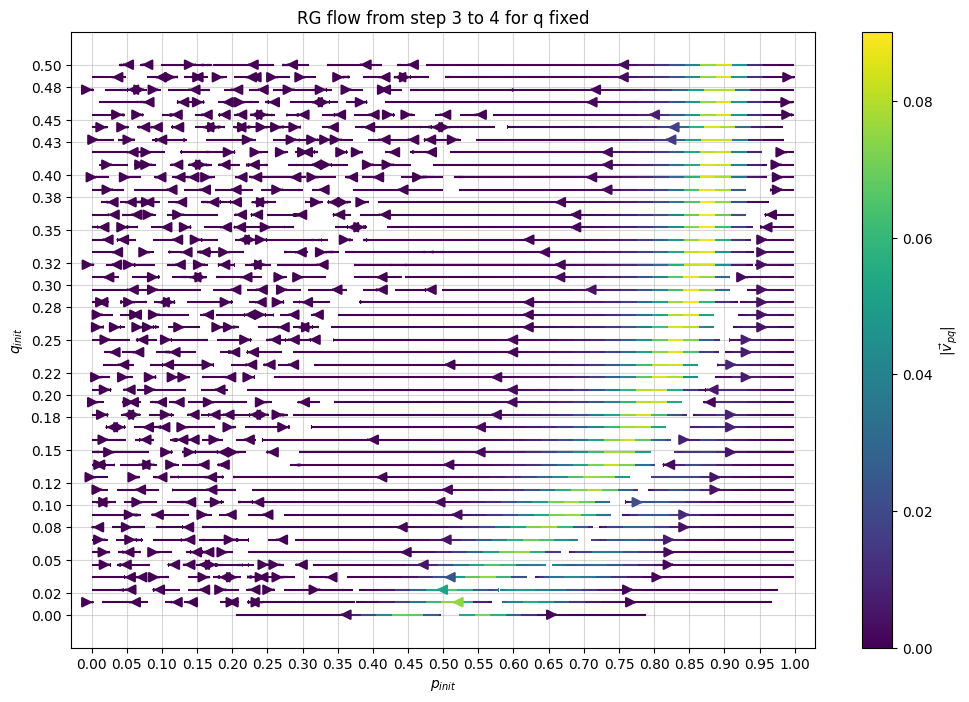

In [76]:
# For individual viewing
close_old_plots()
plot_stream(gs, qs, 3, 4, p_vel, q_vel, streamplotdir, contours=False, save=False, show=True, fixed=datafixed)

### Check grid flow

In [ ]:
gridstep = 1
for i in range(0, numsteps-1, gridstep):
    close_old_plots()
    if i + gridstep < numsteps:
        grid_coords(gs, qs, pdata, qdata, 30, i, i+gridstep, plotdir, False)

### Checking phases

#### Arbitrary bounds check

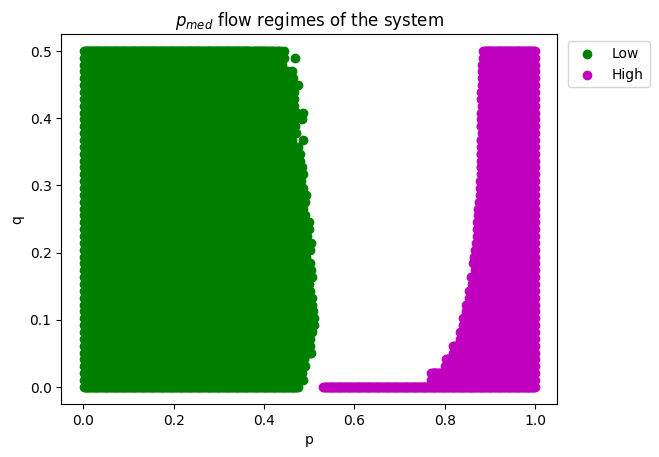

In [6]:
close_old_plots()
# Take the final RG step data for p and q
# p_all, q_all = convert_json_to_array(numsteps, data, qs, gs)
p_all = pdata
q_all = qdata
p_fin = p_all[:, :, numsteps-1, :]
q_fin = q_all[:, :, numsteps-1, :]
# Store the per-step change
del_p = np.empty(shape=(qs.size, gs.size, numsteps-1, 3), dtype=np.float64)
del_q = np.empty(shape=(qs.size, gs.size, numsteps-1, 3), dtype=np.float64)
for s in range(1,numsteps):
    del_p[:, :, s-1, :] = p_all[:,:,s,:] - p_all[:, :, s-1,:]
    del_q[:, :, s-1, :] = q_all[:,:,s,:] - q_all[:,:,s-1,:]

del_speed = np.sqrt(del_p**2 + del_q**2)
# compute overall paths
path_p = np.sum(del_p, axis=2)
path_q = np.sum(del_q, axis=2)
arc_pq = np.sum(del_speed, axis=2)

# Find out which ps end up around 0 or 1
p_ins0 = np.abs(p_fin[:,:,0]) <= 1e-6
p_ins1 = p_fin[:,:,0] >= 1.0 - 2e-6
# Get their indices
q0_indices, p0_indices = np.where(p_ins0)
q1_indices, p1_indices = np.where(p_ins1)
plt.xlabel("p")
plt.ylabel("q")
plt.title(f"$p_{{med}}$ flow regimes of the system")
plt.scatter(gs[p0_indices], qs[q0_indices], label="Low", color="g")
plt.scatter(gs[p1_indices], qs[q1_indices], color="m", label="High")
plt.legend(bbox_to_anchor=(1.2, 1.0))
plt.show()


#### Velocity heatmap

In [79]:
close_old_plots()
# topindex = numsteps-2
vellabels = ["p", "q", "pq"]
speedarrs = {"p": del_p, "q": del_q, "pq": del_speed}
saveheatmap = True
for topindex in range(2, numsteps-2):
    for label in vellabels:
        speed_heatmap(topindex, label, speedarrs[label], gs, qs, plotdir, saveheatmap)
        close_old_plots()


#### Check candidate FPs and eigenvalues

In [80]:
stepchoice = 2
speedtol = 1.0
peaks = find_peaks(stepchoice, pdata, qdata, del_speed, speedtol)
print(len(peaks))
for i in range(0,len(peaks)):
    print(get_jacobian_and_eigenvals(0, 1, numsteps, pdata, qdata, gs, qs, 1,1, peaks[i][0], peaks[i][1]))

Num fp (p) = 5912
Range = 0.0000000 to 1.0000000
Num fp (q) = 5912
Range = 0.0000000 to 0.0000000
6
[-0.06808795  0.25089042]
[-0.06696035 15.89209342]
[-0.06696035 15.89209342]
[-0.06696035 15.89209342]
[-0.06696035 15.89209342]
[-0.06696035 15.89209342]


#### Boundary plots

1, 0.97168
2, 0.97556
3, 0.98288
4, 0.98556
5, 0.98656
6, 0.98856
7, 0.99052


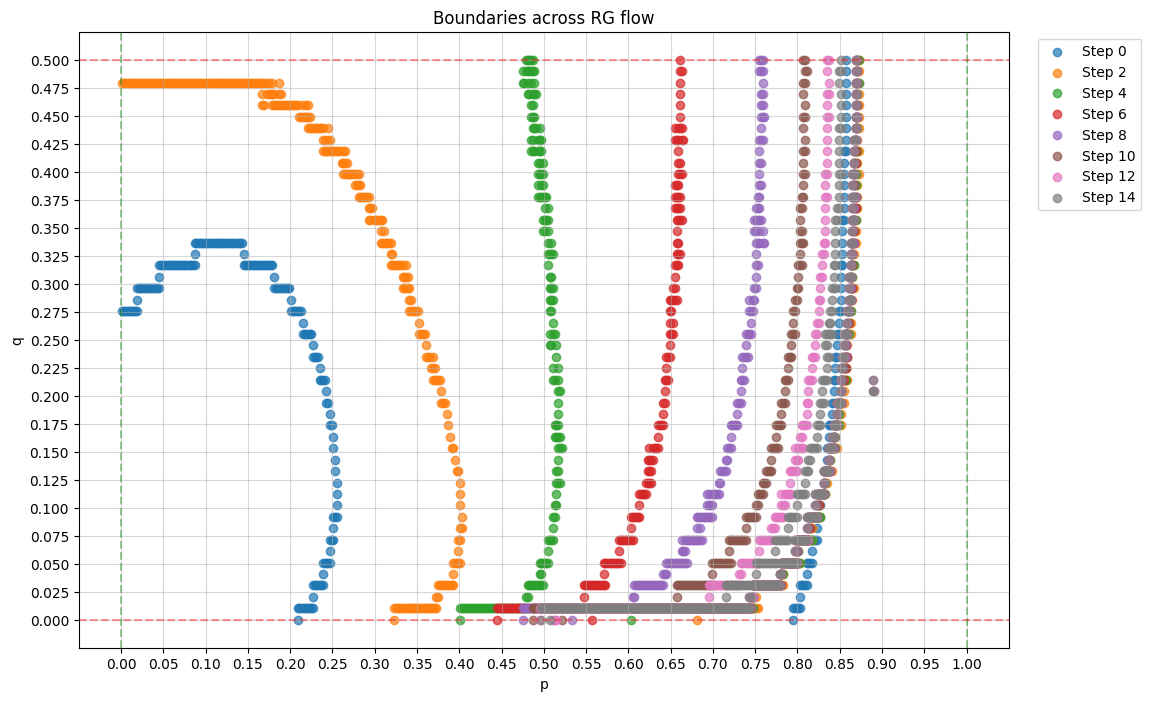

In [122]:
close_old_plots()
# lastindex = 0
cmaps = ["viridis", "Wistia", "autumn", "winter", "summer"]
lower = 0.2
upper = 0.8
plotfit = False
saveboundary = True
plot_boundaries(cmaps, pdata, qdata, numsteps, gs, qs, lower, upper, plotdir, plotfit, saveboundary, s=1e-2)

#### Density Plots

In [82]:
varchoices = list(vardatadict.keys())
for varchoice in varchoices:
    if varchoice == "z":
        varrange = (-5.0, 5.0)
        varbins = 200
    else:
        varbins = 50
        varrange = XLIMS["FP"][varchoice]
    # plt.ioff()
    plot_densities(varbins, varrange, varchoice, vardatadict[varchoice], numsteps, plotdir, save=True)
    close_old_plots()

### Gamma Analysis

In [ ]:
# A reproduction of kobayashi's gamma(p) idea
# Our z is ~ system size / Xi.
# print(qs.size)
gammas = np.empty(shape=(qs.size, gs.size, numsteps), dtype=np.float64)
for j in range(qs.size):
    for k in range(numsteps):
        zn = zdata[j, :, k, 0]
        system_size = 2**(k+1)
        gamma = zn / system_size
        # gamma = zn/2
        gammas[j, :, k] = gamma
# Plot all gammas once
savegamma = False
gamma_start = 5
gamma_end = 10
# f = f"{plotdir}/Gamma/{gamma_start}to{gamma_end-1}"
# os.makedirs(f, exist_ok = True)
# for plotq in range(qs.size):
#     plot_gammas(plotq, numsteps, gammas, gs, qs, f, gamma_start, gamma_end, savegamma)
#     close_old_plots()

-2.223452220468979 2.2204573070685134
-2.0166426283807586 2.0095276436335765
-1.9575765013761106 1.9375883044526232
-1.9436346036222942 1.9144418636666471
-1.9406942499302031 1.9124053946709643
-1.939534277466291 1.9004516343646838
-1.9470385131040355 1.8987437770728743
-1.9537164950273718 1.8817083736461406
-1.9560537114744412 1.866592283910175
-1.9666754512549525 1.8526223994753699
-1.9840420698828716 1.832137682714896


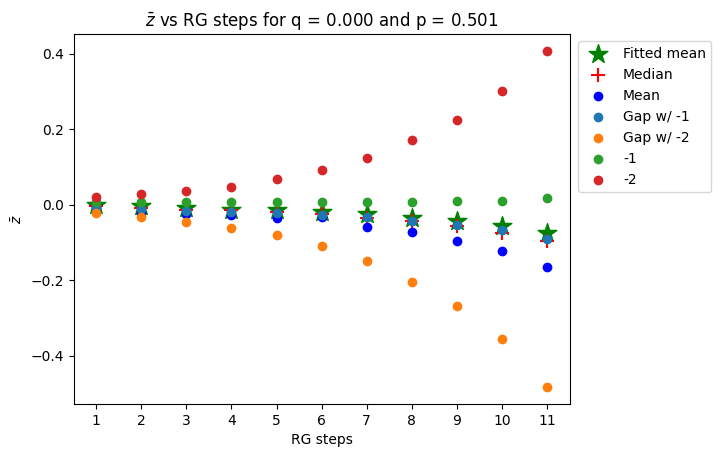

In [8]:
# Individual viewing
plt.ion()
plotq = 0
plotp = 249 +1
start = 1
end = 12
# plot_gammas(plotq, numsteps, zdata[:, :, :, 0], gs[:], qs, f, start, end, False)
close_old_plots()
# print(zdata[plotq, plotp, :, 0])
from scipy.stats import norm
# z = norm.pdf(range(1,numsteps+1), loc=zdata[plotq, plotp, :, 1], scale = zdata[plotq, plotp, :, 2])
# print(z.shape)
xs = range(start, end)
fitmeans = np.empty((len(xs)))
fitstds = np.empty((len(xs)))
for i in range(len(xs)):
    x = np.linspace(zdata[plotq, plotp, i, 0] - 2.5*zdata[plotq, plotp, i, 2], zdata[plotq, plotp, i, 0] + 2.5*zdata[plotq, plotp, i, 2], 200) # Plot the data simply over a range of 4 STDs
    print(x.min(), x.max())
    fitmean, fitstd = norm.fit(x, loc=zdata[plotq, plotp, i, 0], scale=zdata[plotq, plotp, i, 2])
    fitmeans[i] = fitmean
    fitstds[i] = fitstd
    # print(fitparams)
    fittedz = norm.pdf(x, loc=fitmean, scale=fitstd)
    unfitz = norm.pdf(x, loc = zdata[plotq, plotp, i, 0], scale = zdata[plotq, plotp, i, 2])
    # print(zdata[plotq, plotp, i, 0], zdata[plotq, plotp, i, 1], zdata[plotq, plotp, i, 2])
    # print(fitmean, fitstd)
plt.scatter(range(start, end), fitmeans, label="Fitted mean", marker="*", color="g", s = 200)
plt.scatter(range(start, end), zdata[plotq, plotp, start:end, 0], label="Median", marker="+", color="r", s=100)
plt.scatter(range(start, end), zdata[plotq, plotp, start:end, 1], label="Mean", marker="o", color="b")
plt.scatter(range(start, end), fitmeans - zdata[plotq, plotp-1, start:end, 0], label="Gap w/ -1")
plt.scatter(range(start, end), fitmeans - zdata[plotq, plotp-2, start:end, 0], label="Gap w/ -2")
plt.scatter(range(start, end), zdata[plotq, plotp-1, start:end, 0], label="-1")
plt.scatter(range(start, end), zdata[plotq, plotp-2, start:end, 0], label="-2")
plt.xticks(xs)
plt.xlabel("RG steps")
plt.ylabel(r"$\bar{z}$")
plt.title(f"$\\bar{{z}}$ vs RG steps for q = {qs[plotq]:.3f} and p = {gs[plotp]:.3f}")
    # plt.plot(x[::10], fittedz[::10], label=f"Fitted {i}")
    # plt.plot(x[::10], unfitz[::10], label=f"Step {i}", linestyle="--")
    # plt.plot(gs[::10], z[::10, i], label=f"Step {i}")
    # plt.plot(gs[::10], fittedz[::10], linestyle="--", label=f"Fitted {i}")
    # plt.plot(x[::10], z[::10, i], label=f"Step {i}")
    # plt.plot(x[::10], fittedz[::10], linestyle="--", label=f"Fitted {i}")
plt.legend(loc="upper right", bbox_to_anchor=(1.30, 1.0))
plt.show()

In [9]:
# Restrict the range of our analysis to where the crossing mainly lies
val_region = np.where(np.logical_and(gs > 0.3, gs < 0.95))
val_start = np.min(val_region)
val_end = np.max(val_region)
qregmax = 0.5
qreg = np.where(qs <= qregmax)
qgamma = qs[np.min(qreg):np.max(qreg)]
print(qgamma)
print(val_start, val_end)
# qs = qs[0:50]
# print(qs)

[0.         0.01020408 0.02040816 0.03061224 0.04081633 0.05102041
 0.06122449 0.07142857 0.08163265 0.09183673 0.10204082 0.1122449
 0.12244898 0.13265306 0.14285714 0.15306122 0.16326531 0.17346939
 0.18367347 0.19387755 0.20408163 0.21428571 0.2244898  0.23469388
 0.24489796 0.25510204 0.26530612 0.2755102  0.28571429 0.29591837
 0.30612245 0.31632653 0.32653061 0.33673469 0.34693878 0.35714286
 0.36734694 0.37755102 0.3877551  0.39795918 0.40816327 0.41836735
 0.42857143 0.43877551 0.44897959 0.45918367 0.46938776 0.47959184
 0.48979592]
150 474


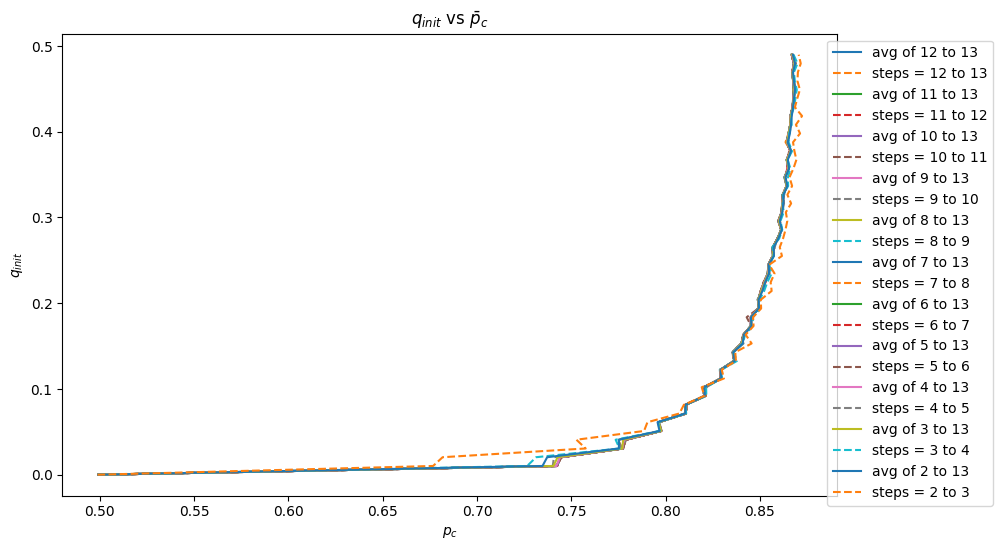

In [10]:
savecrossings = False
showcrossing = False
crossingstep = 2
endcrossing = 14
crossings = plot_crossings(zdata[:, :, :, 0], gs[::], qgamma, numsteps, crossingstep, endcrossing, val_start, val_end, plotdir, savecrossings, showcrossing)
# crossings = plot_crossings(gammas, gs, qgamma, numsteps, crossingstep, endcrossing, val_start, val_end, plotdir, savecrossings, showcrossing)

In [37]:
print(crossings.shape)
print(np.where(np.isnan(crossings)))
print(qs[33])
qchoice = 34
stepc = 8
pchoice = np.argwhere(np.abs(gs - crossings[qchoice, stepc]) < 2e-3)
print(pchoice)
print(zdata[qchoice, pchoice, stepc, 0])

(49, 11)
(array([], dtype=int64), array([], dtype=int64))
0.336734693877551
[[430]
 [431]]
[[-1.57472417]
 [-1.74565389]]


[   8   16   32   64  128  256  512 1024 2048 4096 8192]


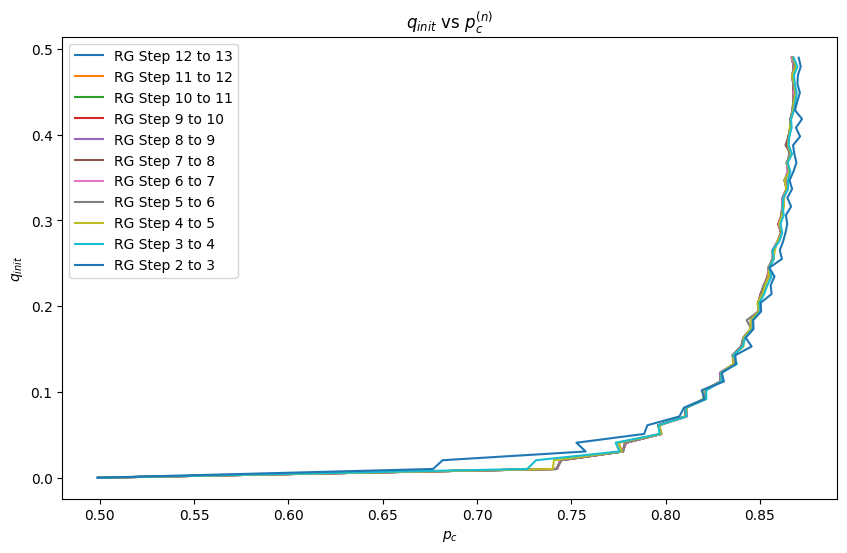

In [12]:
# Plot only the consecutive crossings
close_old_plots()
plt.figure(figsize=(10,6))
plt.xlabel(r"$p_c$")
plt.ylabel(r"$q_{init}$")
plt.plot(crossings, qgamma, label=[f"RG Step {i+crossingstep} to {i+crossingstep+1}" for i in range(crossings.shape[1])[::-1]])
xu = np.array([2**((k)) for k in range(crossingstep+1, endcrossing)])
# plt.plot(xu, crossings)
print(xu)
plt.title("$q_{{init}}$ vs $p_c^{{(n)}}$")
plt.legend()
plt.show()

In [13]:
# Fit consecutive crossings to p_c^(k) = p_c + A*2^(ky) with y = -1
fits = np.empty(shape=(qgamma.size, xu.size))
print(xu.size, crossings.shape)
r2s = np.empty(shape=(qgamma.size, xu.size), dtype=np.float64)

for a in range(endcrossing-crossingstep-2):
    for q in range(qgamma.size):
        coef = np.polyfit(xu[a:], crossings[q, a:], 1)
        y = np.polyval(coef, xu[a:])
        res = np.sum((crossings[q, a:] - y)**2)
        tot = np.sum((crossings[q, a:] - np.mean(crossings[q, a:]))**2)
        r2 = 1 - (res/tot) if tot >= 1e-12 else np.nan
        # print(r2)
        r2s[q, a] = r2
        # print(r2)
        # print(coef[-1])
        fits[q, a] = coef[-1]

# print(y, coef)
# print(fits[-1, :])
# print(np.isnan(fits).sum())

11 (49, 11)


In [70]:
print(np.isnan(r2s).sum())
print(np.where(np.isnan(r2s)))
# print(r2s[:])
print(np.isnan(fits).sum())
# print(fits[1, 5])
# print(fits.shape)
r2choice = r2s[:, :-1]
# print(r2choice[0, :])

print(np.argmax(r2choice, axis=0), np.argmax(r2choice[:, :-1], axis=1)) # For each q, which step has the best R2. For each step, which q has the best r2.
# print(r2choice[:, 1])
print(r2choice[:, 8])
print(fits[:, 9])
# print(r2s[1, :])
# print(r2s[29, :])
# for i in range(r2s.shape[1]):
#     plt.plot(qgamma, r2s[:, i], label=f"{i}")
# plt.legend()
# plt.show()

0
(array([], dtype=int64), array([], dtype=int64))
0
[47 47 47 47 47 47 30  8 46  0] [7 8 8 8 6 8 8 7 7 7 7 7 8 7 7 7 0 8 8 4 8 7 8 8 6 7 0 8 0 8 7 0 0 8 6 7 8
 8 8 8 8 8 6 7 8 7 8 8 8]
[0.68241039 0.98351733 0.96658948 0.92434081 0.92613356 0.94514198
 0.93523111 0.82327974 0.99335865 0.04163594 0.27931788 0.82812353
 0.99984687 0.3019801  0.92948106 0.83851127 0.84788338 0.80344667
 0.66367367 0.92964635 0.88852291 0.97701635 0.99529079 0.96168784
 0.52133875 0.90781675 0.64406552 0.99980379 0.92488265 0.97009823
 0.99144248 0.78576376 0.8164785  0.99712579 0.83543394 0.98992452
 0.91052819 0.99757739 0.94464097 0.90009914 0.99897946 0.88289532
 0.95532901 0.98413253 0.99031172 0.97616193 0.99987997 0.99933033
 0.93800812]
[0.49892853 0.77648934 0.7809055  0.7935487  0.79431026 0.80516137
 0.80187498 0.81450079 0.81130915 0.82258921 0.82381075 0.82849856
 0.82932198 0.83836404 0.83517498 0.83615664 0.84185583 0.84576606
 0.8461398  0.84960774 0.84914205 0.84828674 0.85217105 0.854685

i = 9
i = 8
i = 7
i = 6
i = 5
i = 4
i = 3
i = 2
i = 1
i = 0


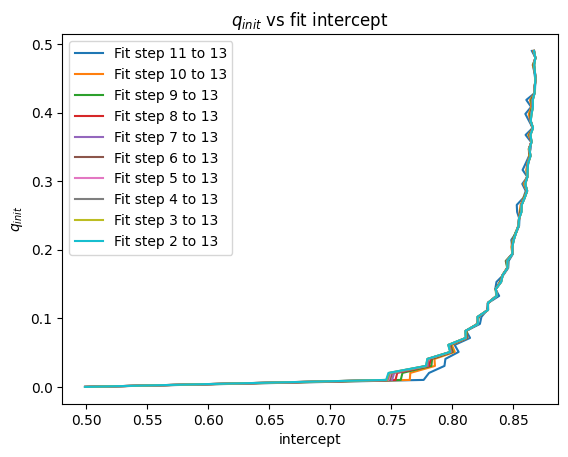

[0.49892853 0.77648934 0.7809055  0.7935487  0.79431026 0.80516137
 0.80187498 0.81450079 0.81130915 0.82258921 0.82381075 0.82849856
 0.82932198 0.83836404 0.83517498 0.83615664 0.84185583 0.84576606
 0.8461398  0.84960774 0.84914205 0.84828674 0.85217105 0.8546857
 0.85496868 0.85306872 0.85276882 0.85816705 0.86011575 0.8573125
 0.86145397 0.85756429 0.86026429 0.86286082 0.86407186 0.86449372
 0.86000698 0.86585941 0.86282524 0.85980289 0.86458747 0.86059798
 0.86761315 0.86782078 0.86789665 0.86712452 0.86590685 0.86820727
 0.8651399 ]


In [71]:
# Plot the fit; the assumption that y = -1
for i in range(endcrossing-crossingstep-2)[::-1]:
    print(f"i = {i}")
    plt.plot(fits[:, i], qgamma, label=f"Fit step {i+2} to {endcrossing-1}")
plt.xlabel("intercept")
plt.ylabel(r"$q_{init}$")
plt.title(r"$q_{init}$ vs fit intercept")
plt.legend()
plt.savefig(f"{plotdir}/Nu/fitted_pc.png", dpi=150)
plt.show()
print(fits[:, -2])
# print(fits[:, 9])
# qgamma = qs[0:25]

In [149]:
# Get the slopes for all q and n
slopes = np.empty(shape=(qgamma.size, endcrossing-crossingstep-1))
gammar2s = np.empty(shape=(qgamma.size, endcrossing-crossingstep-1))
for q in range(qgamma.size):
    for k in range(endcrossing-crossingstep-1):
        # slopes[q, k] = gamma_slope(gs, zdata[q, :, k, 0], crossings[q, k], 10, 2)
        # slopes[q, k] = gamma_slope(gs[::], gammas[q, :, k], crossings[q, k], 10, 2)
        slopes[q, k], gammar2s[q, k] = gamma_slope(gs[::], gammas[q, :, k], crossings[q, k], 10, 2)
        # slopes[q, k], gammar2s[q, k] = gamma_slope(gs[::], zdata[q, :, k, 0], crossings[q, k], 10, 2)
# print(crossings[:, -1]/(1-qgamma))
# plt.plot(qgamma, crossings[:, -1]/(1-qgamma))
# plt.show()

System sizes used are k = 3 to 13


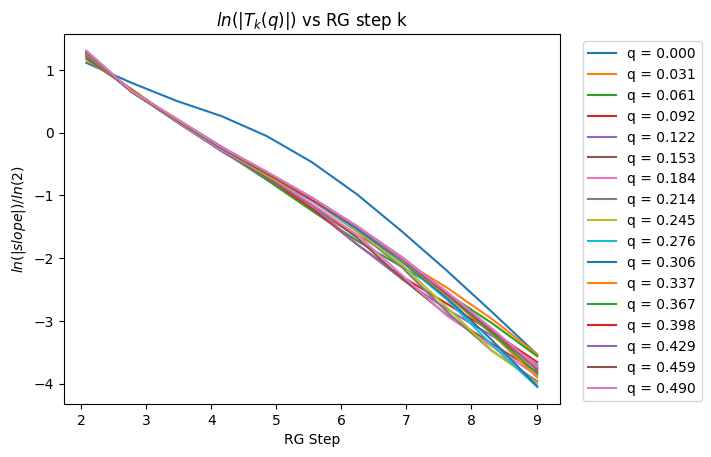

In [150]:
actual_k = np.array(range(crossingstep+1, slopes.shape[1]+crossingstep+1))
sys_size = np.array([2**(i) for i in actual_k])
print(f"System sizes used are k = {crossingstep+1} to {slopes.shape[1]+crossingstep}")
# Set T_k(q) = dGamma/dp at p = p_c for all q at a particular step k.
for q in range(0,qgamma.size, 3):
    # plt.plot(actual_k, np.abs(slopes[q, :]), label=f"q = {qgamma[q]:.3f}")
    # plt.plot(np.log(sys_size), np.log(np.abs(slopes[q, :])), label=f"q = {qgamma[q]:.3f}")
    plt.plot(np.log(sys_size), np.log(np.abs(slopes[q, :])), label=f"q = {qgamma[q]:.3f}")
plt.xlabel("RG Step")
plt.ylabel(r"$ln(|slope|)/ln(2)$")
plt.title(r"$ln(|T_k(q)|)$ vs RG step k")
plt.legend(loc = "upper right", bbox_to_anchor=(1.3, 1.0))
# plt.savefig(f"{plotdir}/Nu/slopes_vs_steps.png", dpi=150, bbox_inches="tight")
plt.show()

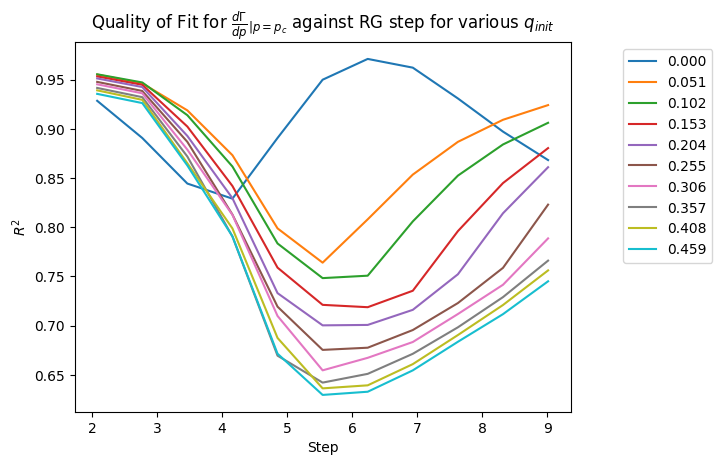

In [144]:
for q in range(0, qgamma.size, 5):
    plt.plot(np.log(sys_size), gammar2s[q, :], label=f"{qgamma[q]:.3f}")
plt.xlabel("Step")
plt.ylabel(r"$R^2$")
plt.legend(loc="upper right", bbox_to_anchor = (1.3, 1.0))
plt.title(r"Quality of Fit for $\frac{d\Gamma}{dp}_{|p=p_c}$ against RG step for various $q_{init}$")
# Conclusion - steps 2 or 3 must be the start, steps 7-9 should be the end.
# This is a check for the gradient at p = p_c for a step number, i.e at a certain system size.
plt.show()

Median of nu for start = 1 and end = 9 is 2.864, R2 = 0.997
Nu at q = 0 is 2.563 and R2 = 0.970
Median of nu for start = 2 and end = 8 is 2.719, R2 = 0.998
Nu at q = 0 is 2.497 and R2 = 0.975
Median of nu for start = 3 and end = 7 is 2.552, R2 = 0.999
Nu at q = 0 is 2.486 and R2 = 0.989
[   8   16   32   64  128  256  512 1024 2048 4096 8192]


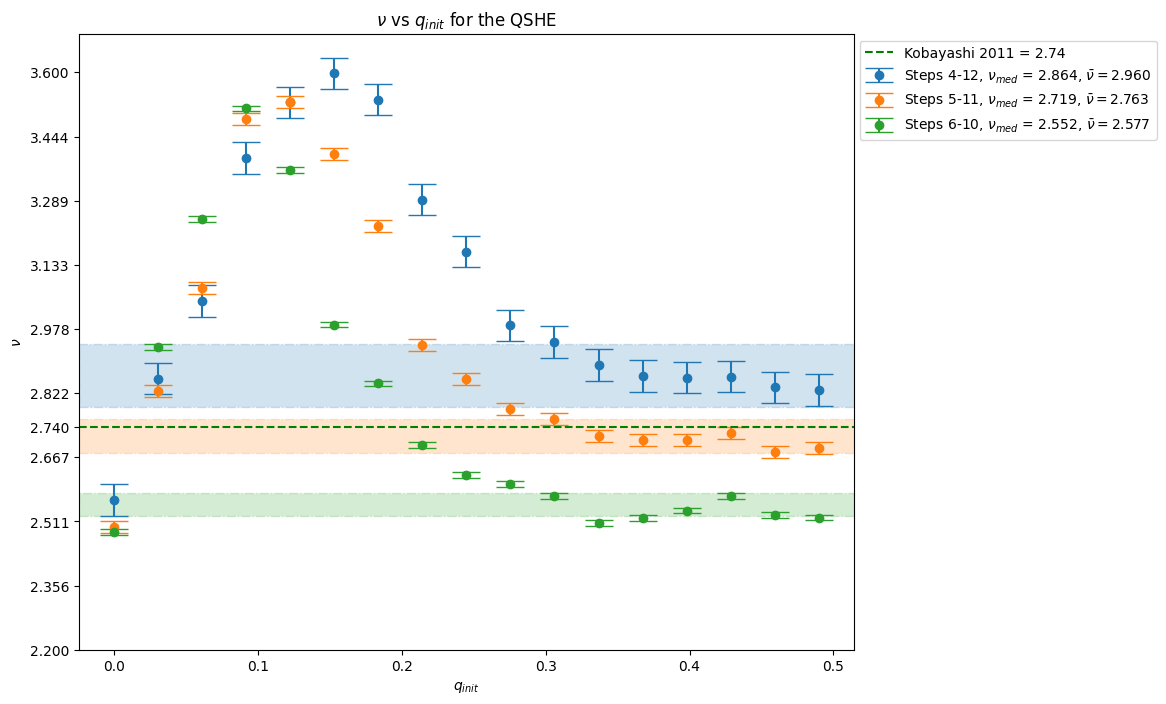

In [146]:
# I have the slopes of dGamma/dp at p = p_c.
logslope = np.log(np.abs(slopes))
# logslope = np.log(slopes)
logsize = np.log(sys_size)
nutests = np.empty(qgamma.size)
fitr2s = np.empty(shape=nutests.shape)
# print(logslope.shape, logsize.shape)
plt.figure(figsize = (10, 8))
startstep = 2
endstep = 8
endjump = 5
additional_ticks = []
for startstep in range(5):
    for endstep in range(startstep+3, 12):
        for i in range(qgamma.size)[::]:
            # plt.plot(logsize, logslope[i, :])
            f = np.polyfit(logsize[startstep:endstep], logslope[i, startstep:endstep], 1)
            preds = np.polyval(f, logsize[startstep:endstep])
            ymean = np.mean(logslope[i, startstep:endstep])
            res = np.sum((logslope[i, startstep:endstep] - preds)**2)
            tot = np.sum((logslope[i, startstep:endstep] - ymean)**2)
            r = 1 - (res/tot)
            fitr2s[i] = r
            slope = f[0]
            intercept = f[1]
            nutest = 1/(slope+1)
            # nutest = 1/slope
            nutests[i] = nutest
            # print(nutest)
        # a = plt.scatter(qgamma[::3], nutests[::3], marker="x", label=f"Steps {startstep}-{endstep}")
        mednu = np.median(nutests[25:])
        # color = a.get_facecolor()[0]
        stdnu = np.std(nutests[20:])
        if np.abs(mednu - 2.74) <= 0.2 and np.abs(nutests[0] - 2.5) <=0.2:
            # print(stdnu)
            # a = plt.scatter(qgamma[::3], nutests[::3], marker="x", label=f"Steps {startstep}-{endstep}, $\\nu_{{med}}$ = {mednu:.3f}, $\\bar{{\\nu}}={np.mean(nutests[20:]):.3f}$")
            a = plt.errorbar(qgamma[::3], nutests[::3], stdnu/np.sqrt(2**(startstep+actual_k[0])), label=f"Steps {startstep+actual_k[0]}-{endstep+actual_k[0]}, $\\nu_{{med}}$ = {mednu:.3f}, $\\bar{{\\nu}}={np.mean(nutests[20:]):.3f}$", linestyle="none", capsize=10, marker="o")
            color = a[0].get_color()
            plt.axhspan(mednu - 0.5*stdnu, mednu+0.5*stdnu, alpha=0.2, color=color, linestyle="-.")
            additional_ticks.append(np.round(mednu, 3))
            print(f"Median of nu for start = {startstep} and end = {endstep} is {mednu:.3f}, R2 = {np.median(fitr2s):.3f}")
            print(f"Nu at q = 0 is {nutests[0]:.3f} and R2 = {fitr2s[0]:.3f}")
        # plt.axhline(mednu, linestyle="--", color=color, label=f"Median = {mednu:.3f}")
plt.axhline(2.74, linestyle="--", color="g", label="Kobayashi 2011 = 2.74")
    # print(nutests[0])
plt.axvspan(0.1, 0.3,2.5, 2.9, alpha=0.4, linestyle="-.")
plt.xlabel(r"$q_{init}$")
plt.ylabel(r"$\nu$")
plt.title("$\\nu$ vs $q_{{init}}$ for the QSHE")
# c = plt.gca().get_yticks()
# newticks = sorted(list(c) + additional_ticks)
# plt.yticks(ticks=newticks)
print(sys_size)
plt.yticks(sorted(list(np.linspace(2.2, 3.6, 10)) + [2.74]))
plt.legend(bbox_to_anchor=(1.4, 1.0))
# plt.savefig("./report/nu_qshe.pdf", bbox_inches="tight")
plt.show()
close_old_plots()

In [117]:
print(fitr2s)

[0.85007578 0.96085499 0.9621493  0.98903797 0.98935153 0.99492392
 0.99640465 0.9932289  0.99652932 0.9894586  0.99097276 0.97744529
 0.97784324 0.97378633 0.96868758 0.96401643 0.96174183 0.95707093
 0.95474885 0.92513522 0.92237907 0.89304578 0.90679583 0.87276644
 0.86409497 0.82780169 0.83052177 0.82981929 0.82511767 0.82439955
 0.83449844 0.84941115 0.85807927 0.90346538 0.90497826 0.94248442
 0.93007411 0.93921857 0.9406889  0.95057103 0.94714806 0.95440892
 0.95639117 0.95556142 0.95361378 0.95591296 0.95982907 0.95813404
 0.95971146]


R2 = 0.9454689317174361, Nu = 2.372802146775042, start = 3, end = 12
R2 = 0.9304715068478993, Nu = 2.5629449752340485, start = 4, end = 12
R2 = 0.9163315876224986, Nu = 2.9014895804687653, start = 5, end = 12
R2 = 0.9161392448608238, Nu = 3.528458501163156, start = 6, end = 12
R2 = 0.9265534616802698, Nu = 4.5174233726558155, start = 7, end = 12
R2 = 0.9501467482948357, Nu = 6.058168860593781, start = 8, end = 12
R2 = 0.9869900235488914, Nu = 8.33298766157045, start = 9, end = 12
R2 = 1.0, Nu = 10.401383232483507, start = 10, end = 12
R2 = 1.0, Nu = 1.710120038347811, start = 4, end = 6
R2 = 0.9991188192930379, Nu = 1.6221547879054579, start = 4, end = 7
R2 = 0.9989628646368337, Nu = 1.6733040273379851, start = 4, end = 8
R2 = 0.9934318269349892, Nu = 1.8030136374302332, start = 4, end = 9
R2 = 0.9802156690892267, Nu = 1.9976993606269975, start = 4, end = 10
R2 = 0.9576736613474365, Nu = 2.2570650884999064, start = 4, end = 11
R2 = 0.9304715068478993, Nu = 2.5629449752340485, start = 4

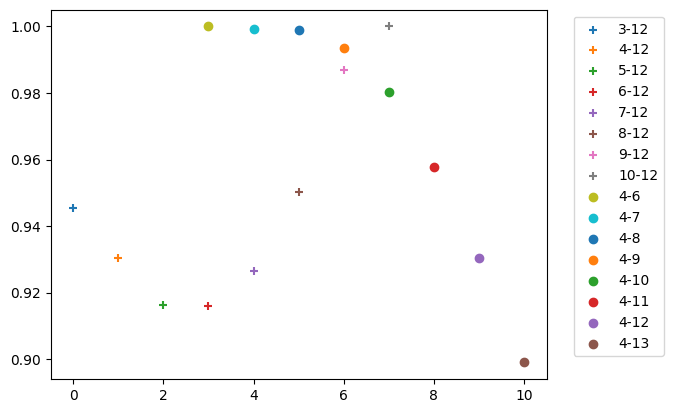

In [133]:
endstep = 9
for s in range(endstep-1):
    f = np.polyfit(logsize[s:endstep], logslope[0, s:endstep], 1)
    slope = f[0]
    intercept = f[1]
    nutest = 1/(slope)
    preds = np.polyval(f, logsize[s:endstep])
    ymean = np.mean(logslope[0, s:endstep])
    res = np.sum((logslope[0, s:endstep] - preds)**2)
    tot = np.sum((logslope[0, s:endstep] - ymean)**2)
    r = 1 - (res/tot)
    # nutests[i] = nutest
    # plt.scatter(s, nutest)
    plt.scatter(s, r, marker="+", label=f"{s+actual_k[0]}-{endstep+actual_k[0]}")
    # print(r)
    print(f"R2 = {r}, Nu = {nutest}, start = {s+actual_k[0]}, end = {endstep+actual_k[0]}")
    # print(nutest)
# plt.show()
startstep = 1
for e in range(sys_size.size)[startstep+2:]:
    f = np.polyfit(logsize[startstep:e], logslope[0, startstep:e], 1)
    slope = f[0]
    intercept = f[1]
    nutest = 1/(slope)
    preds = np.polyval(f, logsize[startstep:e])
    ymean = np.mean(logslope[0, startstep:e])
    res = np.sum((logslope[0, startstep:e] - preds)**2)
    tot = np.sum((logslope[0, startstep:e] - ymean)**2)
    r = 1 - (res/tot)
    # nutests[i] = nutest
    # plt.scatter(e, nutest)
    plt.scatter(e, r, label=f"{startstep+actual_k[0]}-{e+actual_k[0]}")
    # print(r)
    print(f"R2 = {r}, Nu = {nutest}, start = {startstep+actual_k[0]}, end = {e+actual_k[0]}")
    # print(nutest)
plt.legend(bbox_to_anchor = (1.25, 1.0))
plt.show()

In [126]:
nus = np.empty(shape=(qgamma.size, endcrossing-crossingstep-1))
nuslopes = np.empty(shape=(qgamma.size, endcrossing-crossingstep-1))
nuspread = np.empty(shape=(qgamma.size))
for stepchoice in range(crossingstep+1, endcrossing):
    for q in range(qgamma.size):
        # nu, m, b = fit_nu(actual_k, sys_size*slopes[q, :], stepchoice)
        nu, m, b = fit_nu(actual_k, slopes[q, :], stepchoice)
        # nus[q, stepchoice-crossingstep-1] = nu
        nus[q, stepchoice-crossingstep-1] = nu
        nuslopes[q, stepchoice-crossingstep-1] = m
nuspread = np.abs(nus[:, -2] - nus[:, 0])
# print(nuspread)

In [127]:
print(nus.shape)
print(nus[::3, :])
# print(*range(crossingstep, endcrossing-1))

(49, 11)
[[   2.96891872    3.31749836    3.899087      4.91820907    6.53615402
     9.07291032   12.84902822   17.64560535   26.25286436   37.82364631
            nan]
 [   2.96545148    2.93981193    2.90210985    2.89536252    2.90514068
     2.92811728    3.1540499     3.59032042    4.26240708    5.20060605
            nan]
 [   3.08236061    3.03934607    3.00287744    2.98873283    2.96567401
     2.92757995    2.9500644     3.17011259    3.56064909    4.0980296
            nan]
 [   3.35159896    3.31082895    3.32454997    3.36418298    3.39637009
     3.28289567    3.01112562    2.88713298    3.02848794    3.29781499
            nan]
 [   3.47917762    3.44526194    3.49151338    3.57492874    3.69047279
     3.63523993    3.18989673    2.89642915    2.77978389    3.03014982
            nan]
 [   3.70635223    3.70736137    3.85465818    4.08722659    4.41755936
     4.62487886    4.30258715    3.45143083    2.9085129     2.85431872
            nan]
 [   3.77571892    3.79510

### Disorder potential

Critical points found — maxima: 54, minima: 43, saddles: 73


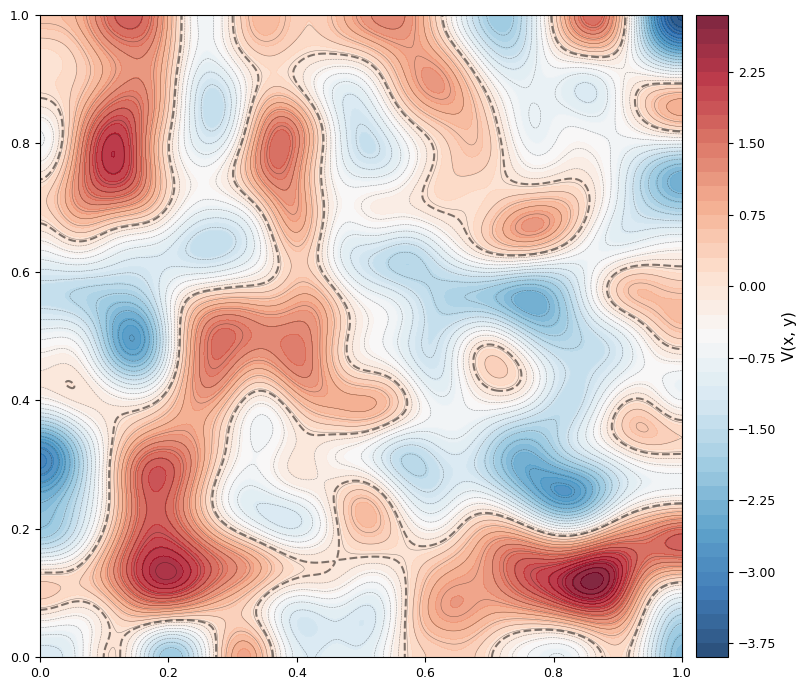

Saved → chalker_coddington.pdf


In [53]:
"""
2D Disordered Potential for the Chalker-Coddington Network Model
----------------------------------------------------------------
Generates a smooth random potential V(x,y), identifies its critical points
(maxima, minima, saddle points), and plots the landscape with annotated
topology — consistent with the physical picture in:

  Chalker, J. T. & Coddington, P. D. (1988).
  Percolation, quantum tunnelling and the integer Hall effect.
  J. Phys. C: Solid State Phys., 21, 2665–2679.

In the CC model electrons drift along iso-potential contours and tunnel
quantum-mechanically at saddle-point nodes. The network is therefore
defined entirely by the saddle-point geometry of V(x,y).

Critical-point classification uses the 2×2 Hessian H of V:
  det(H) > 0, tr(H) < 0  →  maximum
  det(H) > 0, tr(H) > 0  →  minimum
  det(H) < 0              →  saddle point
(Morse theory; see e.g. Nakahara, "Geometry, Topology and Physics", §2.4)
"""

# import numpy as np
# import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
from scipy.signal import argrelextrema

# ── Reproducibility ──────────────────────────────────────────────────────────
RNG = np.random.default_rng(seed=42)

# ── Grid parameters ──────────────────────────────────────────────────────────
N        = 400          # grid points per axis
L        = 1.0          # physical side length
x        = np.linspace(0, L, N)
y        = np.linspace(0, L, N)
X, Y     = np.meshgrid(x, y)
dx       = x[1] - x[0]

# ── Generate smooth random potential ─────────────────────────────────────────
# White noise → Gaussian smoothed to correlation length xi.
# xi controls how many saddle points appear; smaller xi → denser network.
xi_pixels = 18          # correlation length in grid points (~4.5 % of L)
raw       = RNG.standard_normal((N, N))
V         = gaussian_filter(raw, sigma=xi_pixels)
V        /= V.std()     # normalise to unit variance

# ── Numerical gradient and Hessian ───────────────────────────────────────────
Vy, Vx   = np.gradient(V,  dx)          # first derivatives
Vxx, Vxy = np.gradient(Vx, dx)
Vyx, Vyy = np.gradient(Vy, dx)

grad_mag  = np.sqrt(Vx**2 + Vy**2)

# ── Locate critical points ────────────────────────────────────────────────────
# A critical point sits where |∇V| has a local minimum near zero.
# We threshold on the gradient magnitude, then classify by the Hessian.

GRAD_THRESH = 0.12 * grad_mag.max()   # tune to control point density
border      = 15                       # ignore edge artefacts (pixels)

# Binary mask: small gradient
low_grad = (grad_mag < GRAD_THRESH)

# Restrict to interior
mask = np.zeros_like(low_grad, dtype=bool)
mask[border:-border, border:-border] = True
candidates = np.argwhere(low_grad & mask)

# Classify each candidate by det(H) and tr(H)
maxima  = []
minima  = []
saddles = []

# Simple non-maximum-suppression to avoid clustering
MIN_SEP = xi_pixels * dx  # minimum separation in physical units

def _too_close(pt, existing, min_sep):
    if not existing:
        return False
    arr = np.array(existing)
    return np.any(np.linalg.norm(arr - pt, axis=1) < min_sep)

for (j, i) in candidates:
    det_H = Vxx[j, i] * Vyy[j, i] - Vxy[j, i] * Vyx[j, i]
    tr_H  = Vxx[j, i] + Vyy[j, i]
    pt    = np.array([x[i], y[j]])

    if det_H > 0 and tr_H < 0:
        if not _too_close(pt, maxima, MIN_SEP):
            maxima.append(pt)
    elif det_H > 0 and tr_H > 0:
        if not _too_close(pt, minima, MIN_SEP):
            minima.append(pt)
    elif det_H < 0:
        if not _too_close(pt, saddles, MIN_SEP):
            saddles.append(pt)

maxima  = np.array(maxima)  if maxima  else np.empty((0, 2))
minima  = np.array(minima)  if minima  else np.empty((0, 2))
saddles = np.array(saddles) if saddles else np.empty((0, 2))

print(f"Critical points found — maxima: {len(maxima)}, "
      f"minima: {len(minima)}, saddles: {len(saddles)}")

# ── Plotting ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

# Filled-contour background
cf = ax.contourf(X, Y, V, levels=60,
                 cmap="RdBu_r", alpha=0.85)

# Iso-potential lines — the CC drift trajectories
n_iso = 30
iso_levels = np.linspace(V.min(), V.max(), n_iso)
cs = ax.contour(X, Y, V, levels=iso_levels,
                colors="k", linewidths=0.35, alpha=0.45)

ax.contour(X, Y, V, levels=[0.0], colors="k", linestyles="--", alpha=0.5, linewidths=1.5)
# ── Colour bar ───────────────────────────────────────────────────────────────
cbar = fig.colorbar(cf, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label("V(x, y)", fontsize=11)
cbar.ax.tick_params(labelsize=9)

# ── Annotate critical points ─────────────────────────────────────────────────
MARKER_KW = dict(zorder=5, clip_on=False)

# if len(maxima):
#     ax.scatter(maxima[:, 0], maxima[:, 1],
#                marker="^", s=90, color="#FF4444",
#                edgecolors="white", linewidths=0.7,
#                label=f"Maxima ({len(maxima)})", **MARKER_KW)

# if len(minima):
#     ax.scatter(minima[:, 0], minima[:, 1],
#                marker="v", s=90, color="#4488FF",
#                edgecolors="white", linewidths=0.7,
#                label=f"Minima ({len(minima)})", **MARKER_KW)

# if len(saddles):
#     ax.scatter(saddles[:, 0], saddles[:, 1],
#                marker="X", s=90, color="#FFD700",
#                edgecolors="black", linewidths=0.7,
#                label=f"Saddle nodes ({len(saddles)})", **MARKER_KW)

# ── Labels and legend ────────────────────────────────────────────────────────
# ax.set_xlabel("x  [arb. units]", fontsize=12)
# ax.set_ylabel("y  [arb. units]", fontsize=12)
# ax.set_title("Disordered Potential Landscape\n"
#              "Chalker–Coddington Network Model",
#              fontsize=13, fontweight="bold")
ax.set_aspect("equal")
ax.tick_params(labelsize=9)

# legend = ax.legend(loc="upper right", fontsize=9,
#                    framealpha=0.85, edgecolor="grey")

# Small annotation explaining the physics
note = ("Iso-potential contours (black lines) are\n"
        "the electron drift trajectories; tunnelling\n"
        "occurs quantum-mechanically at saddle nodes.")
# ax.text(0.02, 0.02, note, transform=ax.transAxes,
#         fontsize=7.5, va="bottom", ha="left",
#         bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.75, ec="grey"))

plt.tight_layout()
plt.savefig("./report/chalker_coddington.pdf",
            dpi=180, bbox_inches="tight")
plt.show()
print("Saved → chalker_coddington.pdf")

### Nu

Nu for q = 0.000 at step 3 = 2.9689187235993266, err = 34.85472758343329, 1173.99%
Nu for q = 0.000 at step 4 = 3.317498355185373, err = 7.0883609936616985, 213.67%
Nu for q = 0.000 at step 5 = 3.8990870023214086, err = 7.9444455525806355, 203.75%
Nu for q = 0.000 at step 6 = 4.918209067324149, err = 2.235154562288375, 45.45%
Nu for q = 0.000 at step 7 = 6.536154021418207, err = 2.0929684033909277, 32.02%
Nu for q = 0.000 at step 8 = 9.072910321271095, err = 0.9587489298033551, 10.57%
Nu for q = 0.000 at step 9 = 12.849028223080444, err = 1.0156689903988005, 7.90%
Nu for q = 0.000 at step 10 = 17.64560535372486, err = 0.3683111624978639, 2.09%
Nu for q = 0.000 at step 11 = 26.252864357818417, err = 0.208557809944673, 0.79%
Nu for q = 0.000 at step 12 = 37.82364630703261, err = 0.05378396578903155, 0.14%
Nu for q = 0.000 at step 13 = nan, err = 0.1442282485192008, nan%


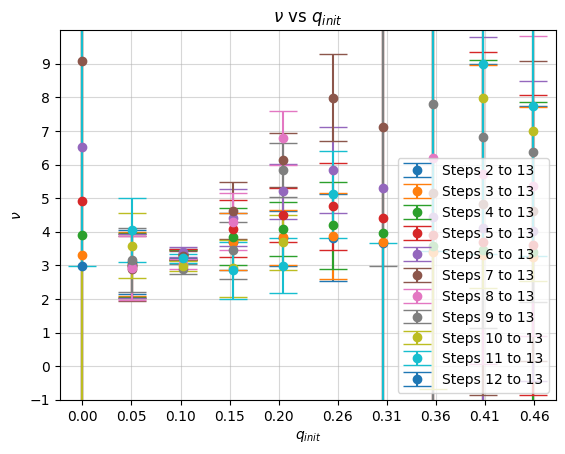

In [124]:
viewchoice = 0
qstep = 5
for i in range(nus.shape[1]):
    # plt.plot(qs, nus[:, i], label=f"Steps {i+3} to {numsteps-1}")
    plt.errorbar(qgamma[::qstep], nus[::qstep, i], yerr=nuspread[::qstep], linestyle="none", marker="o", label=f"Steps {i+crossingstep} to {endcrossing-1}", capsize=10)
    print(f"Nu for q = {qgamma[viewchoice]:.3f} at step {i+3} = {nus[viewchoice, i]}, err = {nuspread[i]}, {nuspread[i]*100/nus[viewchoice, i]:.2f}%")
plt.legend()
# plt.xlim((-0.02, 0.42))
plt.xlabel(r"$q_{init}$")
plt.ylabel(r"$\nu$")
plt.xticks(np.round(qgamma[::qstep], 2))
plt.yticks(range(-1, 10))
plt.ylim((-1, 10))
plt.grid(alpha=0.5)
plt.title(r"$\nu$ vs $q_{init}$")
plt.savefig(f"{plotdir}/Nu/nu_vs_q.png", dpi=150)
plt.show()

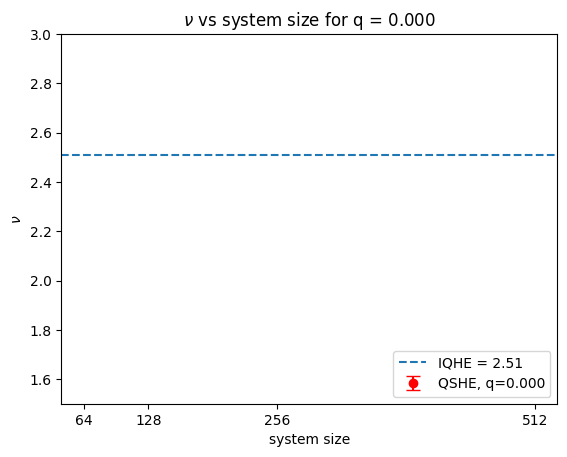

In [351]:
close_old_plots()
plt.errorbar(sys_size[:-1], nus[viewchoice, :-1], yerr = nuspread[viewchoice], marker="o", color="r", capsize=5, linestyle="none", label=f"QSHE, q={qs[viewchoice]:.3f}")
plt.axhline(2.51, linestyle="--", label="IQHE = 2.51")
plt.legend(loc="lower right")
plt.title(f"$\\nu$ vs system size for q = {qs[viewchoice]:.3f}")
plt.xlabel("system size")
plt.ylabel(r"$\nu$")
plt.xticks(sys_size[:-1])
plt.ylim((1.5, 3.0))
plt.savefig(f"{plotdir}/Nu/nu_vs_system_size_q{qs[viewchoice]:.3f}.png", dpi=150)
plt.show()

249
[0.491 0.493 0.495 0.497 0.499]
[0.         0.00640078 0.01280155 0.01920233 0.02560311]
Analysis for p = 0.499
1.3021439000256716 0.999999999263156 5.250875135268111
2.037983524662263 0.9993841272300065 2.9207245590062967
3.1145125825205486 0.999640630342237 2.440502976601845
4.419609279596316 0.999609089284906 2.3321778440784495
6.118811754417795 0.9999190296313005 2.29599025006094
8.614654343048866 0.9998106794735377 2.2531273250854866


11.946292538242789 0.9998879316390672 2.235579155247088
16.21971825561674 0.9999379241929521 2.2389859498949076
22.29327433647504 0.9998946363016058 2.2328722170544664
30.746540964123913 0.9999295140377785 2.2256608867588037
42.620246973848964 0.9998426012595585 2.2166940139078695
59.25828167522947 0.9996237133052457 2.207526177946205


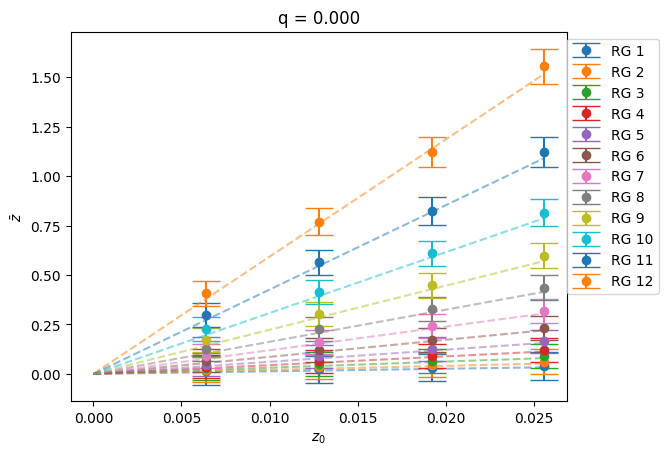

In [ ]:
from source.fitters import fit_z_peaks
# print(zdata.shape)
steprange = range(1, numsteps + 1)
choiceq = 0
choicep = np.argwhere(np.abs(gs - fits[:, :-1][choiceq, -2]) < 2e-3).ravel()[0]
# choicep = 420
print(choicep)
choicepsep = 5
startp = choicep
endp = choicep - choicepsep
# for i in range(choicep-choicepsep, choicep+choicepsep):
#     plt.plot(steprange, zdata[choiceq, i, :, 1], label=f"{gs[i]:.3f}")
close_old_plots()
# pchoices = gs[choicep:choicep+choicepsep]
pchoices = gs[startp:endp:-1]
print(pchoices[::-1])
psep = (cfg.p_max - cfg.p_min) / cfg.p_num
gchoices = pchoices + (1 - pchoices)*qs[choiceq]
zchoices = np.log((1-gchoices)/gchoices)
zshift = (np.max(zchoices) - np.min(zchoices))/zchoices.size
# zaxis = np.abs(zchoices - zchoices[0])
zaxis = np.array(range(pchoices.size)) * zshift
print(zaxis)
# print(zchoices[0], zchoices[-1])
# print(pchoices[0], pchoices[-1])
# print(zchoices)
# print(zshift)
# print(zaxis)
# print(pchoices)
print(f"Analysis for p = {gs[choicep]}")
xs = steprange
fitmeans = np.empty((pchoices.size, len(xs)))
fitstds = np.empty((pchoices.size, len(xs)))
# print(pchoices)
# print(pchoices)
for k in range(pchoices.size):
    i = startp - k
    for m in steprange:
        j = m-steprange[0]
        x = np.linspace(zdata[choiceq, i, j, 0] - 3*zdata[choiceq, i, j, 2], zdata[choiceq, i, j, 0] + 3*zdata[choiceq, i, j, 2], 1000) # Plot the data simply over a range of 4 STDs
        thismean = zdata[choiceq, i, j, 0]
        thisstd = zdata[choiceq, i, j, 2]
        # fitmean, fitstd = norm.fit(x, loc=zdata[plotq, i, steprange[0]:steprange[-1], 0], scale=zdata[plotq, i, steprange[0]:steprange[-1], 2])
        # I want to fit a gaussian to a range of 2.5 std around the mean of z, for each RG step, at this p value
        # fitmean, fitstd = norm.fit(x, loc=thismean, scale=thisstd)
        fitmean, fitstd = norm.fit(x)
        fitmeans[k, j] = fitmean
        fitstds[k, j] = fitstd
# print(fitmeans[:, 0])
# print(fitmeans[0, :])
# print(fitmeans[:, 5] - fitmeans[0, 5])
for i in range(numsteps)[:12:1]:
    # zvals = np.abs(zdata[choiceq, startp:endp:-1, i, 0] - zdata[choiceq, startp, i, 0])
    zvals = fitmeans[:, i]
    # zvals = fitmeans[:, i] - fitmeans[0, i]
    # print(fitmeans[:, i])
    # print(fitmeans[:, i] - fitmeans[0, i])
    # zvals = zdata[choiceq, startp:endp:-1, i, 0]
    s, r2 = fit_z_peaks(zaxis[1:], zvals[1:])
    # fiterrs = fitstds[:, i] / np.sqrt(cfg.samples)
    fiterrs = fitstds[:, i] / np.sqrt(500)
    a = plt.errorbar(zaxis[1:], zvals[1:], yerr=fiterrs[1:], linestyle="none", label=f"RG {i+1}", marker="o", capsize=10)
    c = a.lines[0].get_color()
    # plt.scatter(zaxis, zvals, label=f"RG {i+1}")
    # plt.plot(zaxis, s*zaxis + fitmeans[0, i], linestyle="--", alpha=0.5, color=c)
    plt.plot(zaxis, s*zaxis, linestyle="--", alpha=0.5, color=c)
    nuval = np.log((2**(i+2)))/np.log(s)
    print(s, r2, nuval)
# plt.axhline(zdata[choiceq, choicep, 0, 1], linestyle="--")
# plt.axvline(zchoices[0], linestyle="--", color="r")
#     plt.plot(pchoices, zdata[choiceq, startp:endp:-1, i, 0], label=f"RG {i+1}")
    # plt.plot(gs, zdata[choiceq, :, i, 0], label=f"RG {i+1}")
    # plt.plot(gs, gammas[choiceq, :, i])
# plt.xlim((0.7, 0.9))
plt.title(f"q = {qs[choiceq]:.3f}")
plt.xlabel(r"$z_0$")
plt.ylabel(r"$\bar{z}$")
# plt.ylim((-5.0, 5.0))
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.0))
plt.show()

In [766]:
def get_nus(numsteps, fits, ps, choiceq, zdata):
    close_old_plots()
    steprange = range(0, numsteps + 1)
    # choiceq = 31
    # clippedfits = np.clip(fits[:, :-1], 1e-9, None)
    clippedfits = fits[:, :-1]
    choicep = np.argwhere(np.abs(ps - clippedfits[choiceq, -2]) < 2e-3).ravel()[0] +1
    # print(ps[choicep])
    # print(choicep)
    choicepsep = 10
    startp = choicep
    endp = choicep - choicepsep
    pchoices = ps[startp: endp:-1]
    gchoices = pchoices + (1 - pchoices)*qs[choiceq]
    zchoices = np.log((1-gchoices)/gchoices)
    zshift = (np.max(zchoices) - np.min(zchoices))/zchoices.size
    zaxis = np.abs(zchoices - zchoices[0])
    # print(zaxis)
    met = np.empty(shape=(numsteps, 4))
    xs = steprange
    fitmeans = np.empty((pchoices.size, len(xs)))
    fitstds = np.empty((pchoices.size, len(xs)))
    # print(pchoices)
    # print(pchoices)
    for k in range(pchoices.size):
        i = startp - k
        for m in steprange:
            j = m-steprange[0]
            x = np.linspace(zdata[choiceq, i, j, 0] - 4.5*zdata[choiceq, i, j, 2], zdata[choiceq, i, j, 0] + 4.5*zdata[choiceq, i, j, 2], 200) # Plot the data simply over a range of 4 STDs
            thismean = zdata[choiceq, i, j, 0]
            thisstd = zdata[choiceq, i, j, 2]
            # fitmean, fitstd = norm.fit(x, loc=zdata[plotq, i, steprange[0]:steprange[-1], 0], scale=zdata[plotq, i, steprange[0]:steprange[-1], 2])
            # I want to fit a gaussian to a range of 2.5 std around the mean of z, for each RG step, at this p value
            fitmean, fitstd = norm.fit(x, loc=thismean, scale=thisstd)
            fitmeans[k, j] = fitmean
            fitstds[k, j] = fitstd
            # if k == 0:
            #     print(f"p = {gs[i]:.3f}, q = {qgamma[choiceq]}, step = {j}")
            #     print(f"Actuals: Median = {zdata[choiceq, i, j, 0]:.3f}, Mean = {zdata[choiceq, i, j, 1]:.3f}, STD = {zdata[choiceq, i, j, 2]:.3f}")
            #     print(f"Fits: Mean = {fitmean:.3f}, STD = {fitstd:.3f}")
            #     # print(f"Max err = {np.abs(fitmeans[k, :] - zdata[choiceq, i, steprange[0]:steprange[-1]+1, 0])}")
            #     print("-"*80)
    # print(fitmeans)
    for i in range(numsteps):
        # zvals = np.abs(zdata[choiceq, startp:endp:-1, i, 0] - zdata[choiceq, startp, i, 0])
        # zvals = np.abs(zdata[choiceq, choicep:choicep+choicepsep, i, 0])
        # zvals = fitmeans[:, i]
        zvals = fitmeans[:, i] - fitmeans[0, i]
        # plt.scatter(pchoices, zvals, label=f"RG {i+1}")
        s, r2 = fit_z_peaks(zaxis[:], zvals[:])
        serr = np.sqrt(((zvals - s*zaxis)**2).sum()/(zaxis.size - 1) / (zaxis**2).sum())
        nuval = np.log((2**(i+1)))/np.log(s)
        met[i, :] = np.array([s, r2, nuval, serr])
        # if i > 2:
        #     print(f"Step {i+1}: Slope = {s}, R2 = {r2}, Nu = {nuval}")
    return met

# mets = np.empty(shape=(fits.shape[0], numsteps, 4))
endstep = 13
mets = np.empty(shape=(fits.shape[0], endstep, 4))
for i in range(qgamma.size):
    # mets[i, :, :] = get_nus(numsteps, fits, gs, i, zdata)
    mets[i, :, :] = get_nus(endstep, fits, gs, i, zdata)
# plt.axhline(zdata[choiceq, choicep, 0, 1], linestyle="--")
# plt.axvline(gs[choicep], linestyle="--", color="r")
# plt.title(f"q = {qs[choiceq]:.3f}")
# plt.xlabel("p_init")
# plt.ylabel(r"$\bar{z}$")
# plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.0))
# plt.show()

### TEST

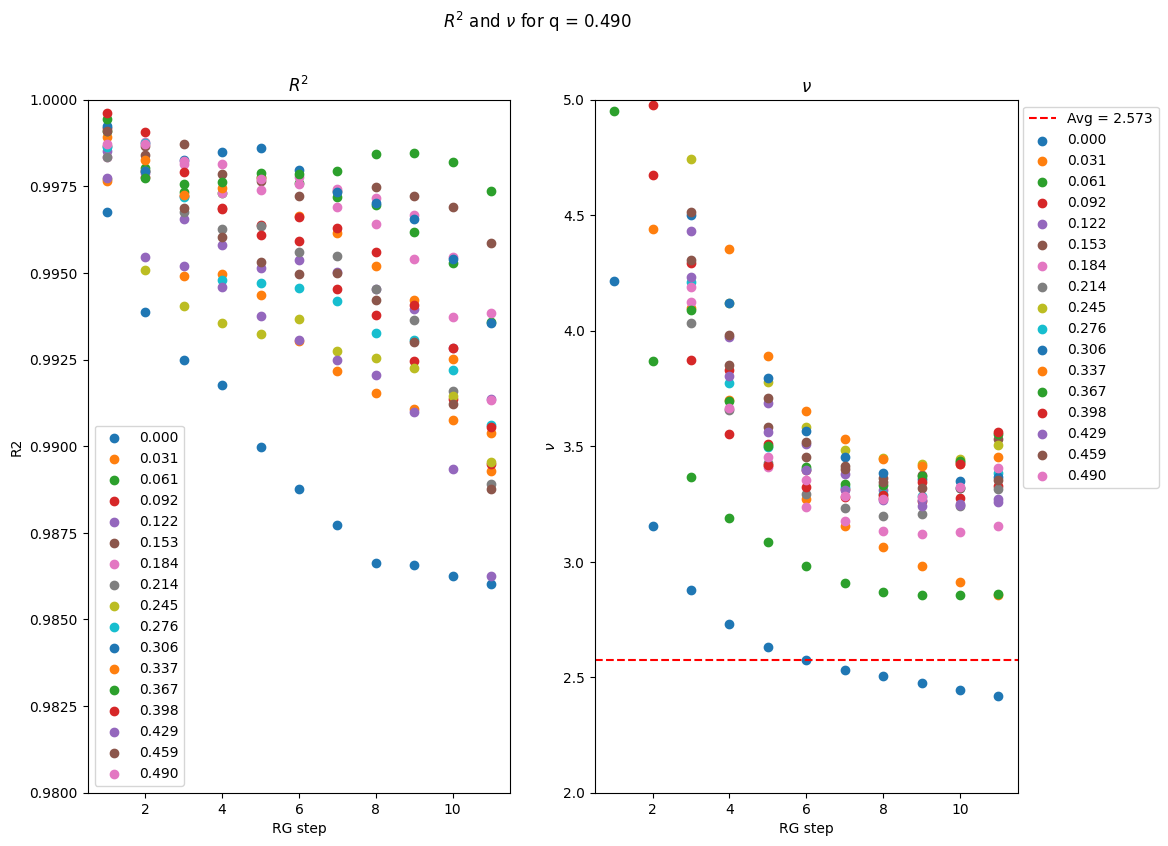

In [582]:
# print(mets.shape)
# print(np.unique(mets[:, :, 2], return_index=True))
qsee = 0
# print(mets[qsee, :, 0])
# print(mets[qsee, :, 1])
# print(mets[qsee, :, 2])
# print(mets[0, qsee, :, 0])
# print(mets[0, qsee, :, 1])
# print(mets[0, qsee, :, 2])
# os.makedirs(f"{plotdir}/Nu/Fits", exist_ok=True)
close_old_plots()
# for qsee in range(qgamma.size):
#     fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 9))
#     ax0.set_xlabel("RG step")
#     ax1.set_xlabel("RG step")
#     ax0.set_ylabel("R2")
#     ax1.set_ylabel(r"$\nu$")
#     for fn in fitnums[:]:
#         ax0.scatter(range(mets.shape[2])[1:-1], mets[fn-1, qsee, 1:-1, 1], label=f"Fitnum = {fn}")
#         ax1.scatter(range(mets.shape[2])[1:-1], mets[fn-1, qsee, 1:-1, 2], label=f"Fitnum = {fn}")
#     avgnu = np.median(mets[:, qsee, 1:-1, 2])
#     ax1.axhline(avgnu, linestyle="--", color="r", label=f"Avg = {avgnu:.3f}")
#     ax1.set_ylim((2.0, 5.0))
#     ax0.set_ylim((0.98, 1.01))
#     ax0.legend(loc="lower left")
#     ax1.legend(loc="upper right", bbox_to_anchor=(1.25, 1.0))
#     ax0.set_title(r"$R^2$")
#     ax1.set_title(r"$\nu$")
#     plt.suptitle(f"$R^2$ and $\\nu$ for q = {qgamma[qsee]:.3f}")
#     fig.savefig(f"{plotdir}/Nu/Fits/fits_{qgamma[qsee]:.3f}.png", dpi=150, bbox_inches="tight")
#     # plt.show()
#     close_old_plots()
# for qsee in range(qgamma.size):
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 9))
ax0.set_xlabel("RG step")
ax1.set_xlabel("RG step")
ax0.set_ylabel("R2")
ax1.set_ylabel(r"$\nu$")
avgnu = np.median(mets[qsee, 1:-1, 2])
ax1.axhline(avgnu, linestyle="--", color="r", label=f"Avg = {avgnu:.3f}")
for qsee in range(qgamma.size)[::3]:
    ax0.scatter(range(mets.shape[1])[1:-1], mets[qsee, 1:-1, 1], label=f"{qgamma[qsee]:.3f}")
    ax1.scatter(range(mets.shape[1])[1:-1], mets[qsee, 1:-1, 2], label=f"{qgamma[qsee]:.3f}")
ax1.set_ylim((2.0, 5.0))
ax0.set_ylim((0.98, 1.00))
ax0.legend(loc="lower left")
ax1.legend(loc="upper right", bbox_to_anchor=(1.35, 1.0))
ax0.set_title(r"$R^2$")
ax1.set_title(r"$\nu$")
plt.suptitle(f"$R^2$ and $\\nu$ for q = {qgamma[qsee]:.3f}")
# fig.savefig(f"{plotdir}/Nu/Fits/fits_{qgamma[qsee]:.3f}.png", dpi=150, bbox_inches="tight")
plt.show()
close_old_plots()

### Back to normal

In [767]:
close_old_plots()
print(mets[0, :, 2])
print(mets[0, :, 0])
numets = mets[:, :, 2]
serrors = mets[:, :, 3]
numeterrs = np.empty(shape=numets.shape)
# print(numets.shape)
for i in range(endstep):
    err = serrors[:, i] * np.log(2**i)/(mets[:, i, 0] * (np.log(mets[:, i, 0])**2))
    # print(err)
    numeterrs[:, i] = err
rmets = mets[:, :, 1]
# numeterrs = np.max(numets, axis=1) - np.min(numets, axis=1)
# rmeterrs = np.max(rmets, axis=1) - np.min(rmets, axis=1)
# numeterrs = np.std(numets, axis=1) / np.sqrt(cfg.samples)

rmeterrs = np.std(rmets, axis=1)
# print(numeterrs.shape)
# print(numets[:, 11])
# print(numeterrs)
# print(np.min(numets[12]), np.max(numets[12]))
# plt.scatter(range(numsteps), mets[25, :, 2])
# plt.show()

[17.23225258  4.21354559  3.15331291  2.87582457  2.73228717  2.62966208
  2.57281011  2.53187912  2.50410869  2.47437211  2.44615763  2.41880256
  2.38067687]
[ 1.04104376  1.38959034  1.93372196  2.62243211  3.55529359  4.86237778
  6.59220199  8.93649137 12.07618779 16.46612663 22.57804071 31.14940089
 44.03662112]


[17.23225258  4.21354559  3.15331291  2.87582457  2.73228717  2.62966208
  2.57281011  2.53187912  2.50410869  2.47437211  2.44615763  2.41880256
  2.38067687]
[0.99999999 0.99675524 0.99388583 0.99250184 0.991769   0.98997479
 0.9887673  0.98771651 0.9866239  0.98657462 0.9862457  0.98601523
 0.98631129]
[0.         0.14267595 0.12453596 0.09315249 0.06195485 0.05468409
 0.04754017 0.04413833 0.03982813 0.03462444 0.03073994 0.02735909
 0.02350932]


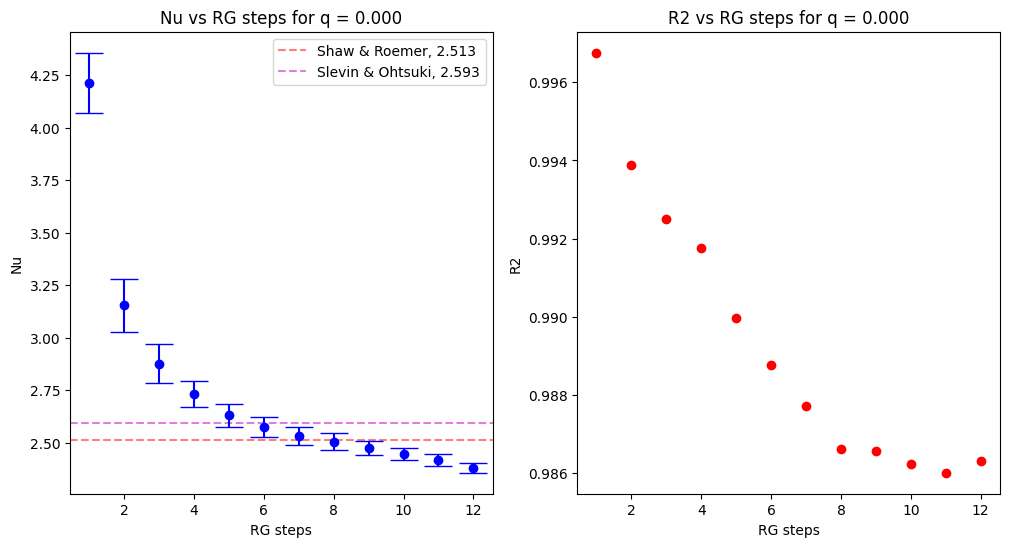

In [768]:
# Nus
# plt.errorbar(qgamma, np.unique(numets[:, 0]), numeterrs,linestyle="none", capsize=20)
qview = 0
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 6))
h0 = ax0.axhline(2.513, linestyle="--", color="r", label="Shaw & Roemer, 2.513", alpha=0.5)
h1 = ax0.axhline(2.593, linestyle="--", color="m", label="Slevin & Ohtsuki, 2.593", alpha=0.5)
ax0.set_title(f"Nu vs RG steps for q = {qgamma[qview]:.3f}")
ax0.set_xlabel("RG steps")
ax0.set_ylabel("Nu")
ax0.errorbar(range(1, endstep), numets[qview, 1:], numeterrs[qview, 1:], marker="o", linestyle="none", capsize=10, color="b")
ax1.set_title(f"R2 vs RG steps for q = {qgamma[qview]:.3f}")
ax1.set_xlabel("RG steps")
ax1.set_ylabel("R2")
ax1.scatter(range(1, endstep), rmets[qview, 1:], marker="o", color="r")
print(numets[qview])
print(rmets[qview])
print(numeterrs[qview])
ax0.legend()
plt.show()
# plt.show()

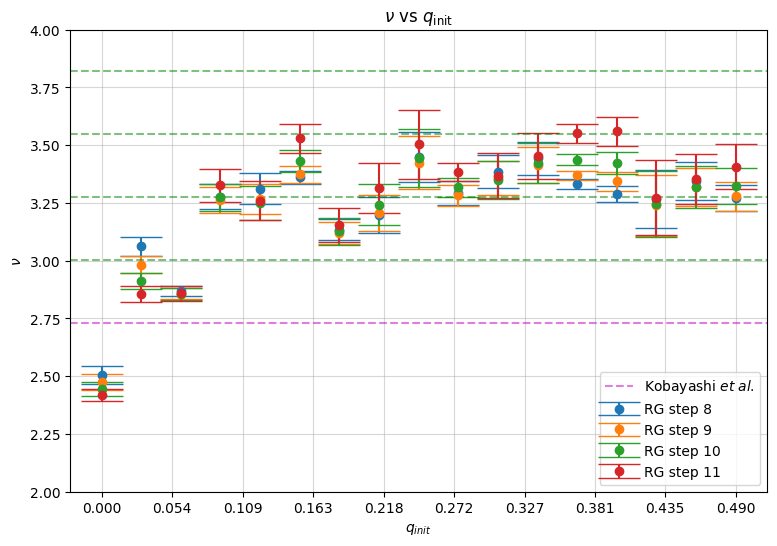

In [573]:
# close_old_plots()
# nustep = 10
indexskip = 3
fig, ax = plt.subplots(figsize=(9, 6))
startnu = 8
endnu = 12
for nustep in range(startnu, endnu):
    plt.errorbar(qgamma[::indexskip], numets[::indexskip, nustep], numeterrs[::indexskip, nustep], linestyle="none", capsize=15, marker="o", label=f"RG step {nustep}")
# plt.errorbar(qgamma[::indexskip], numets[::indexskip, nustep], numeterrs[::indexskip], linestyle="none", capsize=15, marker="o", label=f"RG step {nustep}")
# plt.yticks(np.round(np.linspace(np.min(numets[:, nustep]), np.max(numets[:, nustep]), 10), 3))
plt.xticks(np.round(np.linspace(np.min(qgamma), np.max(qgamma), 10), 3))
plt.xlabel(r"$q_{init}$")
plt.ylabel(r"$\nu$")
plt.grid(alpha=0.5)
plt.axhline(2.73, linestyle="--", color="m", alpha=0.5, label=r"Kobayashi $\it{et\; al.}$")
# plt.axhline()
gap = 2.73 - np.min(numets[::indexskip, 5:]) * 1.01
up20 = 2.73 * 1.2
up10 = 2.73 * 1.1
plt.axhline(up10, linestyle="--", color="g", alpha=0.5)
plt.axhline(up20, linestyle="--", color="g", alpha=0.5)
plt.axhline(2.73*1.3, linestyle="--", color="g", alpha=0.5)
plt.axhline(2.73*1.4, linestyle="--", color="g", alpha=0.5)
# ax.set_yticks(np.linspace(2.73-gap, np.max(numets[::indexskip, 6:])*1.01, 8))
# cticks = ax.get_yticks()
# newticks = sorted(list(np.round(cticks, 3))+[2.73])
plt.ylim((2.0, 4.0))
# plt.yticks(ticks=newticks)
plt.legend(loc="lower right")
plt.title(f"$\\nu$ vs $q_{{\\text{{init}}}}$")
# fig.savefig(f"{root_dir}/report/nu_vs_q.pdf")
plt.show()

[17.22778146  4.30409488  3.27737079  2.92980922  2.76036813  2.658924
  2.59590097  2.55702507  2.52488677  2.48799376  2.45300566  2.41762946
  2.36655515  2.30230218  2.22365043]
[0.99999999 0.99702892 0.99442013 0.99318092 0.99274324 0.99121151
 0.99030132 0.98944874 0.98866768 0.98867902 0.98845022 0.98823987
 0.98825077 0.98786809 0.98614085]
0.10636771438859352


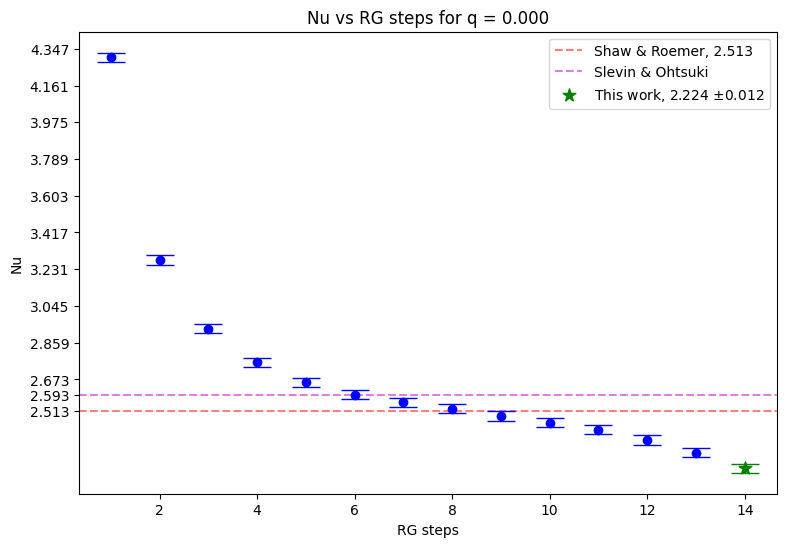

In [289]:
# Nus
# plt.errorbar(qgamma, np.unique(numets[:, 0]), numeterrs,linestyle="none", capsize=20)
qview = 0
fig, ax0= plt.subplots(figsize=(9, 6))
ax0.axhline(2.513, linestyle="--", color="r", label="Shaw & Roemer", alpha=0.5)
ax0.axhline(2.593, linestyle="--", color="m", label="Slevin & Ohtsuki", alpha=0.5)
ax0.set_title(f"Nu vs RG steps for q = {qgamma[qview]:.3f}")
ax0.set_xlabel("RG steps")
ax0.set_ylabel("Nu")
ax0.errorbar(range(1, numsteps-1), numets[qview, 1:-1], 2*numeterrs[qview], marker="o", linestyle="none", capsize=10, color="b")
ax0.errorbar(numsteps-1, numets[qview, -1], 2*numeterrs[qview], linestyle="none", capsize=10, color="g")
ax0.scatter(numsteps-1, numets[qview, -1], marker="*", color="g", s=90, label=f"This work, {numets[qview, -1]:.3f} $\\pm {numeterrs[qview]:.3f}$")
print(numets[qview])
print(rmets[qview])
print(numeterrs[-1])
labels = ["Shaw & Roemer, 2.513", "Slevin & Ohtsuki", f"This work, {numets[qview, -1]:.3f} $\\pm {numeterrs[qview]:.3f}$"]
ax0.legend(labels=labels)
ticks = [2.513, 2.593]
t = np.concat([np.array(ticks), np.linspace(2.673, np.max(numets[qview, 1:]*1.01), 10)])
# ax0.set_yticks(ticks=np.linspace(np.min(numets[qview, 1:])*0.99, np.max(numets[qview, 1:]*1.01), 12))
ax0.set_yticks(t)
# plt.show()
fig.savefig(f"{root_dir}/report/qshe_nu_q0.pdf")
# plt.show()

In [949]:
def S_node(t, r, f):
    S = np.zeros(shape=(t.size, 4, 4), dtype=np.complex128)
    S[:, 0, 0] = t
    S[:, 0, 1] = r
    S[:, 0, 3] = f
    S[:, 1, 1] = -t
    S[:, 1, 0] = r
    S[:, 1, 2] = -f
    S[:, 2, 2] = t
    S[:, 2, 3] = r
    S[:, 2, 1] = -f
    S[:, 3, 3] = -t
    S[:, 3, 2] = r
    S[:, 3, 0] = f

    S_transpose = np.conjugate(np.transpose(S, (0, 2, 1)))
    id_matrix = np.eye(4, dtype=np.complex128)[None, :, :]

    projection = S_transpose @ S
    error = np.max(np.abs(projection - id_matrix))
    print(f"Max error = {error}")
    assert np.allclose(id_matrix, projection, atol=1e-12, rtol=0)
    print("The S matrix is unitary")

inp = np.array([1.0, 0.0, 0.0, 0.0])
N = 1000
rng = build_rng(1234)
indices = rng.integers(0, N, (N, 5))
tstart = rng.uniform(0, 1, N)
fstart = np.sqrt((1 - tstart**2)*0.2)
ts = np.take(tstart, indices)
fs = np.take(fstart, indices)
# ts = generate_constant_array(10000, 0.5, 5)
# fs = generate_constant_array(10000, 0.5, 5)
rs = np.sqrt(1 - ts**2 - fs**2)
# phis = generate_constant_array(100, np.pi*1.2, 16)
phis = generate_random_phases(N, rng, 16)
d = solve_qshe_matrix(ts, fs, phis, N, [2, 9, 10, 17], inp)
# d[2] = np.clip(d[2], 1e-12, 1-1e-12)
# d[9] = np.clip(d[9], 1e-12, 1-1e-12)
# d[10] = np.clip(d[10], 1e-12, 1-1e-12)
# d[17] = np.clip(d[17], 1e-12, 1-1e-12)
# t2 = np.take(d[9], indices)
# f2 = np.take(d[17], indices)
# d = solve_qshe_matrix(t2, f2, phis, N, [2,9,10,17], [1.0, 0.0, 0.0, 0.0])

In [950]:
S_node(ts[:,0], rs[:,0], fs[:,0])
print(np.abs(d[10]).mean())
taup = np.sqrt(np.abs(d[9]) **2 + np.abs(d[10])**2).ravel()
m = np.sqrt(1 - np.abs(d[2])**2 - np.abs(d[17])**2).ravel()
# print(taup, m)
# S_node(np.abs(d[2]).ravel(), np.abs(d[9]).ravel(), np.abs(d[17]).ravel())
S_node(np.abs(d[2]).ravel(), np.abs(taup), np.abs(d[17]).ravel())
S_node(np.abs(d[2]).ravel(), m, np.abs(d[17]).ravel())

Max error = 2.220446049250313e-16
The S matrix is unitary
0.2803226809552167
Max error = 6.439293542825908e-15
The S matrix is unitary
Max error = 2.220446049250313e-16
The S matrix is unitary


In [971]:
def single_node(inputs, t, r, f):
    n = t.size
    S = np.zeros(shape=(n, 4, 4), dtype=np.complex128)
    S[:, 0, 0] = t
    S[:, 0, 1] = r
    S[:, 0, 3] = f
    S[:, 1, 1] = -t
    S[:, 1, 0] = r
    S[:, 1, 2] = -f
    S[:, 2, 2] = t
    S[:, 2, 3] = r
    S[:, 2, 1] = -f
    S[:, 3, 3] = -t
    S[:, 3, 2] = r
    S[:, 3, 0] = f
    if not isinstance(inputs, np.ndarray):
        inputs = np.array(inputs)
    inputs = np.tile(inputs, (N, 1))
    assert inputs.shape == (N, 4)
    outputs = np.einsum('nij,nj->ni', S, inputs)
    return outputs

In [ ]:
tp = d[2].ravel()
rp = d[9].ravel()
tau = d[10].ravel()
taup = np.sqrt(np.abs(rp)**2 + np.abs(tau)**2)
fp = d[17].ravel()
o = single_node(inp, tp, rp, fp) # Outputs from RG into S node
oa = single_node(inp, np.abs(tp), np.abs(rp), np.abs(fp)) # Abs outputs from RG into S node
otau = single_node(inp, np.abs(tp), np.abs(taup), np.abs(fp)) # Using r = sqrt(r'^2 + tau'^2)

In [1107]:
# in the order of the input matrix, outputs are O1_up, O2_up, O1_down, O2_down
print("Number of t'   values that are the same as the output = ", (tp == o[:, 0]).sum())
print("Number of r'   values that are the same as the output = ", (rp == o[:, 1]).sum())
# print("Number of tau' values that are the same as the output = ", (tau == o[:, 2]).sum())
print("Number of f'   values that are the same as the output = ", (fp == o[:, 3]).sum())
print(np.allclose(np.abs(tp)**2 + np.abs(rp)**2 + np.abs(tau)**2 + np.abs(fp)**2, 1.0, atol=1e-12)) # RG outputs sum to 1
print(np.allclose(np.abs(tp)**2 + np.abs(rp)**2 + np.abs(fp)**2, 1.0, atol=1e-12))


Number of t'   values that are the same as the output =  1000
Number of r'   values that are the same as the output =  1000
Number of f'   values that are the same as the output =  1000
True
False


In [ ]:
outsum = np.abs(tp)**2 + np.abs(rp)**2 + np.abs(fp)**2
print(np.allclose(np.abs(o[:, 0])**2 + np.abs(o[:, 1])**2 + np.abs(o[:, 2])**2 + np.abs(o[:, 3])**2, 1, atol=1e-12)) # Saddle node outputs sum to 1
print(np.allclose(np.abs(o[:, 0])**2 + np.abs(o[:, 1])**2 + + np.abs(o[:, 3])**2, outsum, atol=1e-12)) # Saddle node outputs sum to the sum of inputs

False
True


In [997]:
print("Number of t'   values that are the same as the output = ", (np.abs(tp) == oa[:, 0]).sum())
print("Number of r'   values that are the same as the output = ", (np.abs(rp) == oa[:, 1]).sum())
print("Number of tau' values that are the same as the output = ", (np.abs(tau) == oa[:, 2]).sum())
print("Number of f'   values that are the same as the output = ", (np.abs(fp) == oa[:, 3]).sum())

Number of t'   values that are the same as the output =  1000
Number of r'   values that are the same as the output =  1000
Number of tau' values that are the same as the output =  0
Number of f'   values that are the same as the output =  1000


In [999]:
print(np.allclose(np.abs(otau[:, 0])**2 + np.abs(otau[:, 1])**2 + np.abs(otau[:, 2])**2 + np.abs(otau[:, 3])**2, 1, atol=1e-12))
print(np.allclose(np.abs(tp)**2 + np.abs(fp)**2 + np.abs(taup)**2,1, atol=1e-12))
print("Number of t'   values that are the same as the output = ", (np.abs(tp) == otau[:, 0]).sum())
print("Number of r'   values that are the same as the output = ", (np.abs(taup) == otau[:, 1]).sum())
# print("Number of tau' values that are the same as the output = ", (tau == otau[:, 2]).sum())
print("Number of f'   values that are the same as the output = ", (np.abs(fp) == otau[:, 3]).sum())

True
True
Number of t'   values that are the same as the output =  1000
Number of r'   values that are the same as the output =  1000
Number of f'   values that are the same as the output =  1000
